# Land Use prediction

In [ ]:
import pandas as pd
blocks_gdf = pd.read_pickle('./../../data/saint_petersburg/blocks.pickle')

In [ ]:
from blocksnet.analysis.land_use.prediction import SpatialClassifier

In [ ]:
classifier = SpatialClassifier.default()
result = classifier.run(blocks_gdf)

In [ ]:
result

# Land Use Train Mode

In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import os
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from blocksnet.analysis.land_use.prediction import SpatialClassifier
from blocksnet.machine_learning.strategy.sklearn.ensemble.voting.classification_strategy import SKLearnVotingClassificationStrategy

In [ ]:
import pandas as pd
blocks_gdf = pd.read_pickle('./../../data/saint_petersburg/blocks.pickle')

In [ ]:
import pickle
import pandas as pd
import geopandas as gpd
from pathlib import Path

def load_gdfs(root: str | Path, pattern: str = "*.pkl", target_crs: str | None = None) -> list[gpd.GeoDataFrame]:
    """
    Загружает GeoDataFrame'ы из .pkl файлов:
      - если root указывает на один .pkl файл — читаем его и возвращаем список [GDF]
      - если root — папка — рекурсивно ищем по маске pattern и возвращаем список GDF

    Пытаемся заполнить столбцы 'city' и 'country' из структуры путей:
    .../<country>/<city>/<file>.pkl

    Args:
        root: путь к файлу .pkl или папке
        pattern: маска файлов (по умолчанию "*.pkl") — используется только если root папка
        target_crs: если указан, приводим все геоданные к этому CRS

    Returns:
        list[GeoDataFrame]
    """
    p = Path(root)

    def _ensure_gdf(obj):
        """Преобразует объект в GeoDataFrame, если это DataFrame с колонкой 'geometry'."""
        if isinstance(obj, gpd.GeoDataFrame):
            return obj
        if isinstance(obj, pd.DataFrame) and "geometry" in obj.columns:
            return gpd.GeoDataFrame(obj, geometry="geometry", crs=getattr(obj, "crs", None))
        return None

    def _infer_city_country(fp: Path):
        # ожидаем .../<country>/<city>/<file>.pkl
        city = fp.name[:-4] if fp else None
        country = fp.parent.name if len(fp.parents) >= 2 else None
        return city, country

    # Соберём список файлов
    if p.is_file() and p.suffix.lower() == ".pkl":
        files = [p]
    elif p.is_dir():
        files = sorted(p.rglob(pattern))
        files = [f for f in files if f.suffix.lower() == ".pkl"]
    else:
        return []

    gdfs: list[gpd.GeoDataFrame] = []

    for fp in files:
        try:
            with open(fp, "rb") as f:
                obj = pickle.load(f)
        except Exception as e:
            print(f"Пропускаю {fp}: {e}")
            continue

        # Если GeoDataFrame
        gdf = _ensure_gdf(obj)

        # Если dict с GeoDataFrame
        if gdf is None and isinstance(obj, dict):
            for k, v in obj.items():
                gi = _ensure_gdf(v)
                if gi is None:
                    continue
                gi = gi.copy()
                if "city" not in gi.columns or gi["city"].isna().all():
                    gi["city"] = str(k)
                _, country = _infer_city_country(fp)
                if ("country" not in gi.columns) and country:
                    gi["country"] = country
                if target_crs:
                    gi = gi.to_crs(target_crs) if gi.crs else gi.set_crs(target_crs)
                gdfs.append(gi)
            continue

        if gdf is None:
            print(f"Пропускаю {fp}: объект не GeoDataFrame и не dict с GeoDataFrame.")
            continue

        gdf = gdf.copy()
        city, country = _infer_city_country(fp)
        if "city" not in gdf.columns:
            gdf["city"] = city or fp.stem
        if ("country" not in gdf.columns) and country:
            gdf["country"] = country

        if target_crs:
            gdf = gdf.to_crs(target_crs) if gdf.crs else gdf.set_crs(target_crs)

        gdfs.append(gdf)

    return gdfs

blocks_gdf = load_gdfs('data/TANYA-2025 v2/Russia')

In [ ]:
from blocksnet.analysis.land_use.prediction.core import str_to_land_use, land_use_to_category

# def map_and_filter_blocks(blocks):
    # out = []
    # for g in blocks:
    #     gi = g.copy()
    #     gi["category"] = gi["land_use"].map(str_to_land_use).map(land_use_to_category)
    #     if gi["category"].notna().sum() > 99:
    #         out.append(g)
    # return out

# blocks_gdf = map_and_filter_blocks(blocks_gdf)

In [216]:
from blocksnet.analysis.land_use.prediction.core import str_to_land_use, land_use_to_category, category_to_index
from blocksnet.analysis.land_use.prediction.schemas import BlocksInputSchema
import pandas as pd

def normalize_and_filter(data):
    if isinstance(data, (list, tuple)):
        out = []
        for g in data:
            
            gi = BlocksInputSchema(g)
            if 'land_use' in gi:
                gi['category'] = gi['land_use'].map(str_to_land_use).map(land_use_to_category)
            gi = gi[gi['category'].map(category_to_index).notna()]
            if not gi.empty:
                out.append(gi)
        return out
    else:
        g = BlocksInputSchema(data)
        if 'land_use' in g:
            g['category'] = g['land_use'].map(str_to_land_use).map(land_use_to_category)
        return g[g['category'].map(category_to_index).notna()]

blocks_gdf = normalize_and_filter(blocks_gdf)
len(blocks_gdf)

80

In [217]:
city_names = [f"City_{i}" for i in range(len(blocks_gdf))]  # или ваши названия

# Словари для хранения результатов
results_per_city = {}  # проценты по каждому городу
total_area_by_category = {}  # суммарная площадь по категориям (для финального %)

# Обработка каждого города
for i, gdf in enumerate(blocks_gdf):
    city_name = city_names[i] if i < len(city_names) else f"City_{i}"

    if gdf.empty or len(gdf.geometry) == 0:
        print(f"{city_name}: пустой GeoDataFrame")
        continue

    # Оценка наилучшей CRS для точного расчёта площади
    try:
        crs_estimated = gdf.estimate_utm_crs()
    except Exception:
        # Резерв: использовать глобальную равноплощадную проекцию
        centroid = gdf.geometry.to_crs("EPSG:4326").unary_union.centroid
        crs_estimated = f"+proj=laea +lat_0={centroid.y} +lon_0={centroid.x} +units=m"

    # Перепроецирование и расчёт площади
    gdf_proj = gdf.to_crs(crs_estimated)
    gdf_proj['area'] = gdf_proj.geometry.area

    # Преобразуем Enum в строку (например, LandUseCategory.RESIDENTIAL → 'RESIDENTIAL')
    gdf_proj['cat_str'] = gdf_proj['category'].apply(
        lambda x: x.name if (x and hasattr(x, 'name')) else str(x) if x is not None else "Unknown"
    )

    # Суммируем площади по категориям
    area_by_cat = gdf_proj.groupby('cat_str')['area'].sum()

    # Процентное распределение для этого города
    total_city_area = area_by_cat.sum()
    pct_distribution = (area_by_cat / total_city_area * 100).round(2)
    results_per_city[city_name] = pct_distribution

    # Накопление общей площади по категориям (для финальной агрегации)
    for cat, area in area_by_cat.items():
        total_area_by_category[cat] = total_area_by_category.get(cat, 0) + area

# === Общее распределение по всем городам ===
total_all_areas = sum(total_area_by_category.values())
overall_distribution = {
    cat: round((area / total_all_areas) * 100, 2)
    for cat, area in total_area_by_category.items()
}

# Преобразуем в Series или DataFrame для удобства
overall_series = pd.Series(overall_distribution).sort_values(ascending=False)
print("\n=== Общее распределение по всем городам (%) ===")
overall_series

# # Результаты по городам (как DataFrame)
# per_city_df = pd.DataFrame(results_per_city).fillna(0)  # 0% если категории нет
# print("\n=== Распределение по каждому городу (%) ===")
# print(per_city_df)

# # Опционально: добавить строку с общим распределением
# per_city_df_with_total = per_city_df.copy()
# per_city_df_with_total.loc["TOTAL_OVERALL_%"] = overall_series.reindex(per_city_df.index, fill_value=0)


=== Общее распределение по всем городам (%) ===


RESIDENTIAL    34.56
AGRICULTURE    25.90
INDUSTRIAL     24.81
SPECIAL         6.42
RECREATION      6.07
BUSINESS        1.72
TRANSPORT       0.51
dtype: float64

In [218]:
pd.concat(blocks_gdf)['category'].value_counts(), pd.concat(blocks_gdf)['category'].value_counts() / pd.concat(blocks_gdf).shape[0] * 100

(category
 LandUseCategory.RESIDENTIAL    50828
 LandUseCategory.RECREATION      8485
 LandUseCategory.AGRICULTURE     8400
 LandUseCategory.INDUSTRIAL      7272
 LandUseCategory.TRANSPORT       4540
 LandUseCategory.BUSINESS        1517
 LandUseCategory.SPECIAL          688
 Name: count, dtype: int64,
 category
 LandUseCategory.RESIDENTIAL    62.190138
 LandUseCategory.RECREATION     10.381745
 LandUseCategory.AGRICULTURE    10.277744
 LandUseCategory.INDUSTRIAL      8.897590
 LandUseCategory.TRANSPORT       5.554876
 LandUseCategory.BUSINESS        1.856112
 LandUseCategory.SPECIAL         0.841796
 Name: count, dtype: float64)

In [6]:
import pandas as pd
from typing import List, Any

def filter_balanced_cities(
    gdfs: List[pd.DataFrame],
    category_col: str = 'category',
    target_percent: float = 25.0,
    tolerance: float = 10.0,
    required_count: int = 4
) -> List[pd.DataFrame]:
    """
    Фильтрует список датафреймов (городов), оставляя только те,
    где все `required_count` типов из Enum присутствуют и их доля 
    близка к target_percent ± tolerance.

    :param gdfs: Список DataFrame/GeoDataFrame (по одному на город)
    :param category_col: Название колонки с Enum
    :param target_percent: Целевой процент для каждого класса (25%)
    :param tolerance: Допуск в процентах (±10% → от 15% до 35%)
    :param required_count: Количество обязательных уникальных типов (например, 4)
    :return: Отфильтрованный список датафреймов
    """
    lower_bound = target_percent - tolerance  # 15%
    upper_bound = target_percent + tolerance  # 35%
    filtered_gdfs = []

    for i, gdf in enumerate(gdfs):
        if gdf.empty or category_col not in gdf.columns:
            continue

        # Преобразуем Enum в строку по .name
        cat_names = gdf[category_col].apply(lambda x: x.name if hasattr(x, 'name') else str(x))
        
        # Проверяем, что все 4 типа присутствуют
        unique_categories = cat_names.unique()
        if len(unique_categories) < required_count:
            continue  # не хватает типов

        # Считаем доли
        value_counts = cat_names.value_counts(normalize=True) * 100  # в процентах

        # Проверяем, что каждый класс в диапазоне [lower_bound, upper_bound]
        all_within_range = True
        for cat, pct in value_counts.items():
            if not (lower_bound <= pct <= upper_bound):
                all_within_range = False
                break

        if all_within_range:
            filtered_gdfs.append(gdf)

    return filtered_gdfs

In [18]:
# Предположим, у вас есть list_of_city_gdfs — список GDF по городам
tolerance = 25
filtered_cities = filter_balanced_cities(blocks_gdf, required_count=7, tolerance=tolerance)

print(f"Найдено {len(filtered_cities)} городов с равномерным распределением (25% ± {tolerance}%)")

Найдено 12 городов с равномерным распределением (25% ± 25%)


In [ ]:
filtered_cities[2].explore('category')

In [18]:
# 1. Инициализация и обучение
BASE_PARAMS = {"random_state": 42, "n_jobs": -1}
CPU = max(1, min(8, os.cpu_count() or 1))
MODEL_PARAMS = {
    "rf": {
        "n_estimators": 120,          # было 200
        "max_depth": 7,
        "class_weight": "balanced",
        "max_samples": 0.25,          # 🔴 бэггинг на подвыборке
        "min_samples_leaf": 10,       # стабилизация и меньше узлов
        **BASE_PARAMS
    },
    "xgb": {
        "n_estimators": 150,          # меньше
        "max_depth": 7,
        "learning_rate": 0.05,
        "subsample": 0.8,             # стахастичность
        "colsample_bytree": 0.8,
        "tree_method": "hist",        # память/скорость
        "n_jobs": CPU                 # XGB игнорирует BASE_PARAMS если его стерли
    },
    "lgb": {
        "n_estimators": 200,
        "max_depth": 7,
        "learning_rate": 0.05,
        "class_weight": "balanced",
        "num_threads": CPU            # у LGB параметр другое имя
    },
    "hgb": {
        "max_iter": 200,
        "max_depth": 7,
        "learning_rate": 0.05,
        "random_state": 42
    }
}
estimators = [
    ("rf",  RandomForestClassifier(**MODEL_PARAMS["rf"])),
    ("xgb", XGBClassifier(**MODEL_PARAMS["xgb"])),
    ("lgb", LGBMClassifier(**MODEL_PARAMS["lgb"])),
    ("hgb", HistGradientBoostingClassifier(**MODEL_PARAMS["hgb"])),
]

# estimators = [
# ("rf", RandomForestClassifier(n_estimators=400, max_depth=12, min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1)),
# ("xgb", XGBClassifier(n_estimators=600, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, tree_method="hist", n_jobs=8)),
# ("lgb", LGBMClassifier(n_estimators=800, max_depth=10, learning_rate=0.05, class_weight="balanced", num_threads=8)),
# ("hgb", HistGradientBoostingClassifier(max_iter=500, max_depth=8, learning_rate=0.05, random_state=42)),
# ]

strategy = SKLearnVotingClassificationStrategy(estimators, {"voting": "soft", "n_jobs": -1})
classifier = SpatialClassifier(strategy, 1000, 5)


In [144]:
import pandas as pd
from typing import List
from tqdm import tqdm

def balance_dfs_by_category(dfs: List[pd.DataFrame]) -> List[pd.DataFrame]:
    """
    Балансирует каждый DataFrame: 
    - целевой размер = min_count * 2, 
    - но не больше max_count (чтобы не делать oversampling)
    Затем undersample всех классов до этого целевого размера (если возможно).
    
    :param dfs: Список DataFrame или GeoDataFrame
    :return: Список сбалансированных DataFrame
    """
    balanced_dfs = []
    
    for df in tqdm(dfs):
        if df.empty:
            balanced_dfs.append(df)
            continue
        
        if 'category' not in df.columns:
            raise ValueError("Один из DataFrame не содержит колонки 'category'")
        
        # Преобразуем Enum -> строка по .name
        cat_names = df['category'].apply(lambda x: x.name if hasattr(x, 'name') else str(x))
        
        counts = cat_names.value_counts()
        min_count = counts.min()
        max_count = counts.max()
        
        # Целевой размер: min * 2, но не больше max_count
        target_size = min(int(min_count * 1.2), max_count)
        
        # Группируем без сортировки
        grouped = df.groupby(cat_names, sort=False)
        
        # Пробуем взять target_size образцов из каждой группы
        # Если в группе меньше — берём всё (undersample только если больше)
        balanced_df = grouped.apply(
            lambda group: group.sample(
                n=min(len(group), target_size), 
                random_state=42, 
                replace=False
            ),
            include_groups=False
        ).reset_index(drop=True)
        
        balanced_dfs.append(balanced_df)
    
    return balanced_dfs

balanced_gdfs = balance_dfs_by_category(blocks_gdf)

100%|██████████| 156/156 [00:01<00:00, 134.97it/s]


In [ ]:
train_ready = classifier.preprocess_training_data(blocks_gdf)

In [149]:
train_ready.category.value_counts()

category
LandUseCategory.RESIDENTIAL    4128
LandUseCategory.RECREATION     4089
LandUseCategory.INDUSTRIAL     3957
LandUseCategory.BUSINESS       3337
Name: count, dtype: int64

In [150]:
score = classifier.train(train_ready)
score

d:\programming\github\blocksnet\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.6211681187479832

In [ ]:
for i in blocks_gdf:
    gdf = None
    print()
    if i.city[0] == 'Saint Petersburg':
        gdf = i
        break

In [151]:
raw_test = gpd.read_file('data/blocks_best_feature.gpkg')
test_ready = classifier.preprocess_run_data(raw_test)

In [152]:
result = classifier.run(test_ready)

d:\programming\github\blocksnet\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\programming\github\blocksnet\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


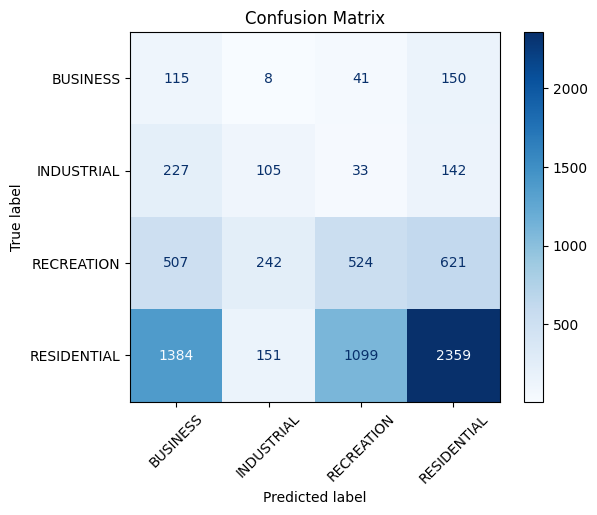

In [153]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Предположим, что result — это ваш DataFrame
true_labels = result[result.category.notna()]['category'].apply(lambda x: x.name)  # Извлекаем истинные метки
pred_labels = result[result.category.notna()]['pred_name']                        # Извлекаем предсказанные метки

# Строим матрицу ошибок
cm = confusion_matrix(true_labels, pred_labels)

# Визуализация
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(set(true_labels) | set(pred_labels)))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

In [154]:
# Получаем строковое представление (через .name), если это Enum
categories = train_ready['category'].apply(lambda x: x.name if hasattr(x, 'name') else str(x))

# Считаем количество
counts = categories.value_counts()

# Считаем проценты
percentages = (counts / counts.sum()) * 100

# Выводим результат
print("Распределение по категориям:")
print("----------------------------")
for category, count in counts.items():
    pct = percentages[category]
    print(f"{category:15} : {count:4} ({pct:.1f}%)")

result = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages.round(1)
})
result

Распределение по категориям:
----------------------------
RESIDENTIAL     : 4128 (26.6%)
RECREATION      : 4089 (26.4%)
INDUSTRIAL      : 3957 (25.5%)
BUSINESS        : 3337 (21.5%)


,Count,Percentage (%)
category,,
RESIDENTIAL,4128,26.6
RECREATION,4089,26.4
INDUSTRIAL,3957,25.5
BUSINESS,3337,21.5


In [36]:
import geopandas as gpd
import folium
from itertools import cycle

# gdf — ваш GeoDataFrame из примера
g = result[0].copy()

# Нормализация имён классов
def norm_cat(v):
    try:
        # Если это Enum LandUseCategory -> берём .value
        from blocksnet.enums import LandUseCategory
        if isinstance(v, LandUseCategory):
            return v.value
    except Exception:
        pass
    if isinstance(v, str):
        s = v.strip()
        # Строки вида "LandUseCategory.RESIDENTIAL" -> "RESIDENTIAL"
        if s.startswith("LandUseCategory."):
            return s.split(".", 1)[1]
        return s.upper()
    return str(v).upper()

g["category_name"] = g["category"].apply(norm_cat)
g["pred_name_norm"] = g["pred_name"].apply(norm_cat)

mism = g[g["category_name"] != g["pred_name_norm"]].copy()
if mism.empty:
    display("Нет несовпадений category и pred_name")
    mism  # Пустой набор на всякий случай
else:
    # Готовим CRS для folium (нужен EPSG:4326)
    if mism.crs is None and g.crs is not None:
        mism = mism.set_crs(g.crs, allow_override=True)
    if mism.crs is None:
        raise ValueError("GeoDataFrame должен иметь установленный CRS")
    mism_wgs = mism.to_crs(epsg=4326)

    # Центр карты
    minx, miny, maxx, maxy = mism_wgs.total_bounds
    center = [(miny + maxy) / 2, (minx + maxx) / 2]

    m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

    # Базовый слой с границами всех полигонов (опционально)
    try:
        all_wgs = g.to_crs(epsg=4326) if g.crs is not None else g
        all_wgs.explore(
            m=m,
            name="Все полигоны (контур)",
            style_kwds=dict(color="#999999", weight=1, fill=False),
            tooltip=False,
            show=False,
        )
    except Exception:
        pass

    # Палитра цветов для слоёв
    colors = cycle([
        "#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
        "#ff7f00", "#ffff33", "#a65628", "#f781bf", "#999999"
    ])

    # Добавляем каждый тип несовпадения отдельным слоем
    for (true_cat, pred_cat), sub in mism_wgs.groupby(["category_name", "pred_name_norm"]):
        color = next(colors)
        layer_name = f"{true_cat} → {pred_cat} ({len(sub)})"
        sub.explore(
            m=m,
            name=layer_name,
            style_kwds=dict(color=color, weight=2, fill=True, fillOpacity=0.4),
            tooltip=["category_name", "pred_name_norm"],
            show=True,
        )

    folium.LayerControl(collapsed=False).add_to(m)
    m  # отобразить карту


In [ ]:
m

In [11]:
classifier.strategy.save('artifacts')

In [ ]:
import pandas as pd
from blocksnet.enums import LandUseCategory

gdf = result[0].copy()

# Нормализуем в строки
def norm_true(v):
    if isinstance(v, LandUseCategory):
        return v.value
    if v is None:
        return None
    s = str(v).strip()
    return s.split(".", 1)[1] if s.startswith("LandUseCategory.") else s.upper()

def norm_pred(s):
    return s.strip().upper() if isinstance(s, str) else str(s).upper()

gdf["true_name"] = gdf["category"].apply(norm_true)
gdf["pred_name_norm"] = gdf["pred_name"].apply(norm_pred)

# Фильтруем только строки с известной истинной категорией
mask = gdf["true_name"].notna()
g = gdf.loc[mask, ["true_name", "pred_name_norm"]]

# Фиксируем порядок классов (столбцы/строки) по enum
classes = [c.value for c in LandUseCategory]

# Матрица ошибок (counts)
cm = pd.crosstab(g["true_name"], g["pred_name_norm"], 
                 rownames=["Actual"], colnames=["Predicted"])
cm = cm.reindex(index=classes, columns=classes, fill_value=0)
display(cm)

# Нормированная по строкам (доли)
cm_norm = cm.div(cm.sum(axis=1).replace(0, 1), axis=0).round(3)
display(cm_norm)


import numpy as np
import pandas as pd
from blocksnet.enums import LandUseCategory

# Берём результат: GeoDataFrame
gdf = result[0].copy()

# 1) Нормализуем истинную метку в строку из набора {INDUSTRIAL, RECREATION, BUSINESS, RESIDENTIAL}
def norm_true(v):
    if isinstance(v, LandUseCategory):
        return v.value
    if v is None:
        return None
    s = str(v).strip()
    return s.split(".", 1)[1] if s.startswith("LandUseCategory.") else s.upper()

gdf["true_name"] = gdf["category"].apply(norm_true)

# 2) Определяем порядок классов и соответствующие им колонки вероятностей
classes = [c.value for c in LandUseCategory]
prob_cols = {cls: f"prob_{cls}" for cls in classes}

# Проверим, что нужные колонки есть (если каких-то нет — считаем их нулевыми)
for cls, col in prob_cols.items():
    if col not in gdf.columns:
        gdf[col] = 0.0

# 3) Оставляем только строки с известной истинной категорией
mask = gdf["true_name"].notna()
g = gdf.loc[mask].copy()

# 4) (Опционально) подстрахуемся: нормируем вероятности по строкам к сумме 1 (на случае, если чуть “плывут”)
P = g[[prob_cols[c] for c in classes]].to_numpy(dtype=float)
row_sums = P.sum(axis=1, keepdims=True)
row_sums_safe = np.where(row_sums > 0, row_sums, 1.0)
P = P / row_sums_safe
g.loc[:, [prob_cols[c] for c in classes]] = P

# 5) Строим мягкую матрицу ошибок
soft_cm = pd.DataFrame(0.0, index=classes, columns=classes)
for true_cls in classes:
    rows = g["true_name"] == true_cls
    if rows.any():
        # Суммируем вероятности по всем объектам с истинным классом true_cls
        sums = [g.loc[rows, prob_cols[pred_cls]].sum() for pred_cls in classes]
        soft_cm.loc[true_cls] = sums

# 6) Нормированная по строкам (доли внутри истинного класса)
soft_cm_norm = soft_cm.div(soft_cm.sum(axis=1).replace(0, 1), axis=0).round(3)

# 7) Ожидаемая точность (expected accuracy): среднее p(true_class) по объектам с известной меткой
# Для каждой строки берём вероятность её истинного класса
correct_probs = g.apply(lambda row: row[prob_cols[row["true_name"]]], axis=1)
expected_accuracy = float(correct_probs.mean()) if len(correct_probs) else float("nan")

display(soft_cm.round(3))
display(soft_cm_norm)
print(f"Expected accuracy (soft): {expected_accuracy:.4f}")


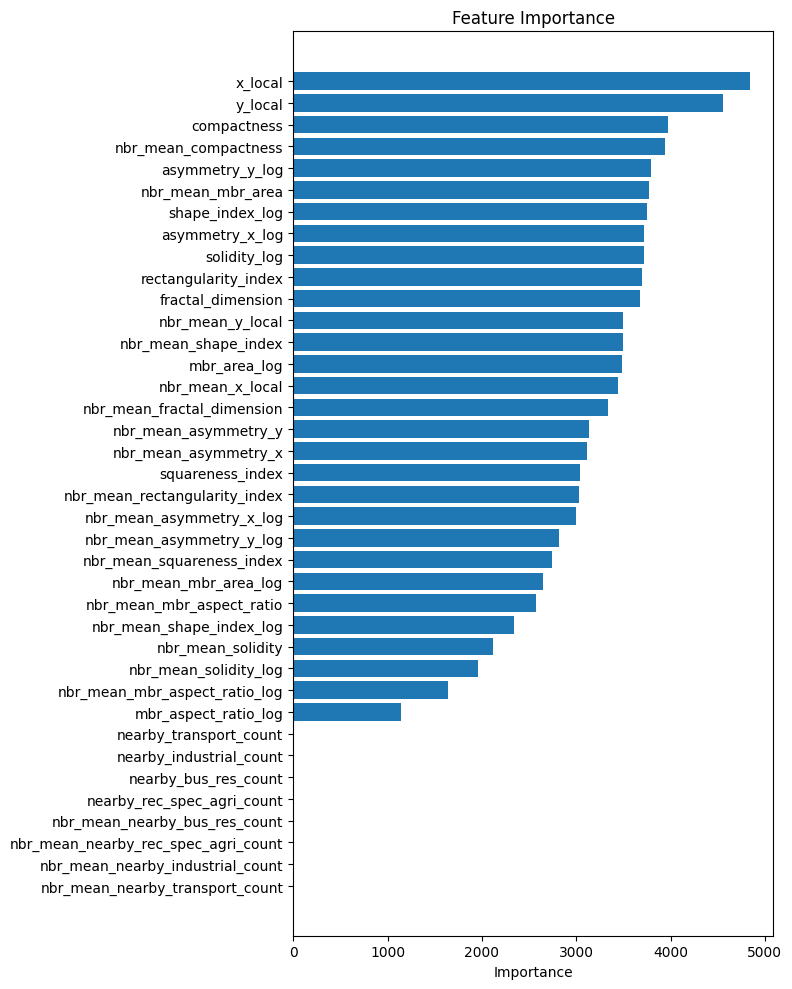

In [25]:
# df = pd.DataFrame([values], columns=columns)

df = pd.DataFrame({
    'feature': classifier.feature_cols,
    'importance': classifier.strategy.model.estimators_[2].feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.barh(df['feature'], df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## ------------------------------------------------------------

In [1]:
import pickle
import osmnx as ox
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from tqdm.notebook import tqdm
from shapely.geometry import Point, MultiPolygon, Polygon

import matplotlib.pyplot as plt
import seaborn as sns

def load_gdfs(root: str | Path, pattern: str = "*.pkl", target_crs: str | None = None) -> list[gpd.GeoDataFrame]:
    """
    Загружает GeoDataFrame'ы из .pkl файлов:
      - если root указывает на один .pkl файл — читаем его и возвращаем список [GDF]
      - если root — папка — рекурсивно ищем по маске pattern и возвращаем список GDF

    Пытаемся заполнить столбцы 'city' и 'country' из структуры путей:
    .../<country>/<city>/<file>.pkl

    Args:
        root: путь к файлу .pkl или папке
        pattern: маска файлов (по умолчанию "*.pkl") — используется только если root папка
        target_crs: если указан, приводим все геоданные к этому CRS

    Returns:
        list[GeoDataFrame]
    """
    p = Path(root)

    def _ensure_gdf(obj):
        """Преобразует объект в GeoDataFrame, если это DataFrame с колонкой 'geometry'."""
        if isinstance(obj, gpd.GeoDataFrame):
            return obj
        if isinstance(obj, pd.DataFrame) and "geometry" in obj.columns:
            return gpd.GeoDataFrame(obj, geometry="geometry", crs=getattr(obj, "crs", None))
        return None

    def _infer_city_country(fp: Path):
        # ожидаем .../<country>/<city>/<file>.pkl
        city = fp.name[:-4] if fp else None
        country = fp.parent.name if len(fp.parents) >= 2 else None
        return city, country

    # Соберём список файлов
    if p.is_file() and p.suffix.lower() == ".pkl":
        files = [p]
    elif p.is_dir():
        files = sorted(p.rglob(pattern))
        files = [f for f in files if f.suffix.lower() == ".pkl"]
    else:
        return []

    gdfs: list[gpd.GeoDataFrame] = []

    for fp in files:
        try:
            with open(fp, "rb") as f:
                obj = pickle.load(f)
        except Exception as e:
            print(f"Пропускаю {fp}: {e}")
            continue

        # Если GeoDataFrame
        gdf = _ensure_gdf(obj)

        # Если dict с GeoDataFrame
        if gdf is None and isinstance(obj, dict):
            for k, v in obj.items():
                gi = _ensure_gdf(v)
                if gi is None:
                    continue
                gi = gi.copy()
                if "city" not in gi.columns or gi["city"].isna().all():
                    gi["city"] = str(k)
                _, country = _infer_city_country(fp)
                if ("country" not in gi.columns) and country:
                    gi["country"] = country
                if target_crs:
                    gi = gi.to_crs(target_crs) if gi.crs else gi.set_crs(target_crs)
                gdfs.append(gi)
            continue

        if gdf is None:
            print(f"Пропускаю {fp}: объект не GeoDataFrame и не dict с GeoDataFrame.")
            continue

        gdf = gdf.copy()
        city, country = _infer_city_country(fp)
        if "city" not in gdf.columns:
            gdf["city"] = city or fp.stem
        if ("country" not in gdf.columns) and country:
            gdf["country"] = country

        if target_crs:
            gdf = gdf.to_crs(target_crs) if gdf.crs else gdf.set_crs(target_crs)

        gdfs.append(gdf)

    return gdfs

blocks_gdf = load_gdfs('data/TANYA-2025 v2/Russia')
spb_test = gpd.read_file('data/blocks_SPB_test.gpkg')[['land_use', 'geometry']]
kem_test = gpd.read_file('data/blocks_KEM_test.gpkg')[['land_use', 'geometry']]

kem_test.loc[kem_test['land_use'] == 'businnes', 'land_use'] = 'business'

In [ ]:
def get_city_boundary(city_name, country_name):
    """
    Возвращает GeoDataFrame с границей города.
    Пытается найти именно город (place=city), а не административный район.
    """
    query = f"city {city_name}, {country_name}"
    
    # --- 1. Попробуем найти как "place=city" ---
    try:
        gdf_city = ox.geocode_to_gdf(
            query,
            which_result=1,           # первый результат
            structure='polygon',      # только полигоны
            tags={'place': 'city'}    # фильтр по типу
        )
        if not gdf_city.empty:
            print(f"✅ Найден город как place=city: {city_name}")
            return gdf_city
    except Exception as e:
        pass  # пробуем следующий вариант
    
    # --- 2. Попробуем admin_level=8 (городской уровень) ---
    try:
        gdf_city = ox.geocode_to_gdf(
            query,
            which_result=1,
            structure='polygon',
            tags={'admin_level': '8'}
        )
        if not gdf_city.empty:
            print(f"✅ Найден город как admin_level=8: {city_name}")
            return gdf_city
    except Exception as e:
        pass
    
    # --- 3. Если ничего не нашли — попробуем просто первую границу ---
    try:
        gdf_city = ox.geocode_to_gdf(query, which_result=1)
        if not gdf_city.empty:
            print(f"⚠️ Используем первую найденную границу (возможно, район): {city_name}")
            return gdf_city
    except Exception as e:
        print(f"❌ Не удалось найти границу для: {query}")
        pass
    
    try:
        query = f"{city_name}, {country_name}"
        gdf_city = ox.geocode_to_gdf(query, which_result=1)
        if not gdf_city.empty:
            print(f"⚠️ Используем первую найденную границу (возможно, район): {city_name}")
            return gdf_city
    except Exception as e:
        print(f"❌ Не удалось найти границу для: {query}")
        return None

# --- Обработка каждого города ---
city_gdfs_with_coverage = []

for index, gdf in enumerate(blocks_gdf):
    gdf = gdf.copy()
    
    # Получаем имя города и страны из первой строки (предполагаем, что весь gdf — один город)
    city_name = gdf['city'].iloc[0]
    country_name = gdf['country'].iloc[0]
    
    # Определяем UTM CRS
    utm_crs = gdf.estimate_utm_crs()
    gdf.to_crs(utm_crs, inplace=True)
    
    # --- Шаг 1: Получаем границу города ---
    city_boundary = get_city_boundary(city_name, country_name)
    
    if city_boundary is None:
        print(f"❌ Пропуск города {city_name}, {country_name} — не найдена граница")
        # Добавляем пустые колонки
        gdf['area_pct_of_city'] = np.nan
        gdf['city_boundary_area_m2'] = np.nan
        gdf['covered_area_ratio'] = np.nan
        city_gdfs_with_coverage.append(gdf)
        continue
    
    # Переводим границу в UTM, если нужно
    if city_boundary.crs != utm_crs:
        city_boundary.to_crs(utm_crs, inplace=True)
    
    # --- Шаг 2: Площадь города ---
    total_city_area = city_boundary.area.values  # в м²
    
    # --- Шаг 3: Площадь каждого квартала ---
    gdf['area_m2'] = gdf.geometry.area
    
    # Доля квартала от общей площади города (%)
    gdf['area_pct_of_city'] = (gdf['area_m2'] / total_city_area) * 100
    
    # --- Шаг 4: Доля непокрытой территории ---
    total_blocks_area = gdf['area_m2'].sum()
    uncovered_ratio = max(0.0, (total_city_area[0] - total_blocks_area) / total_city_area[0])
    
    # Добавляем как колонку (одинаковое значение для всех строк города)
    gdf['city_boundary_area_m2'] = total_city_area[0]
    gdf['covered_area_ratio'] = 1 - uncovered_ratio
    
    # Сохраняем геометрию границы (опционально)
    gdf['city_boundary_geometry'] = city_boundary['geometry'].iloc[0]
    
    # --- Лог ---
    # print(f"{index:>3}. 🏙️ {city_name}, {country_name}")
    # print(f"   Площадь города: {total_city_area[0]:,.0f} м²")
    # print(f"   Сумма кварталов: {total_blocks_area:,.0f} м²")
    print(f"   Покрытие: {100*(1 - uncovered_ratio):.1f}% | Не размечено: {100*uncovered_ratio:.1f}%")
    print("-" * 50)
    
    city_gdfs_with_coverage.append(gdf)

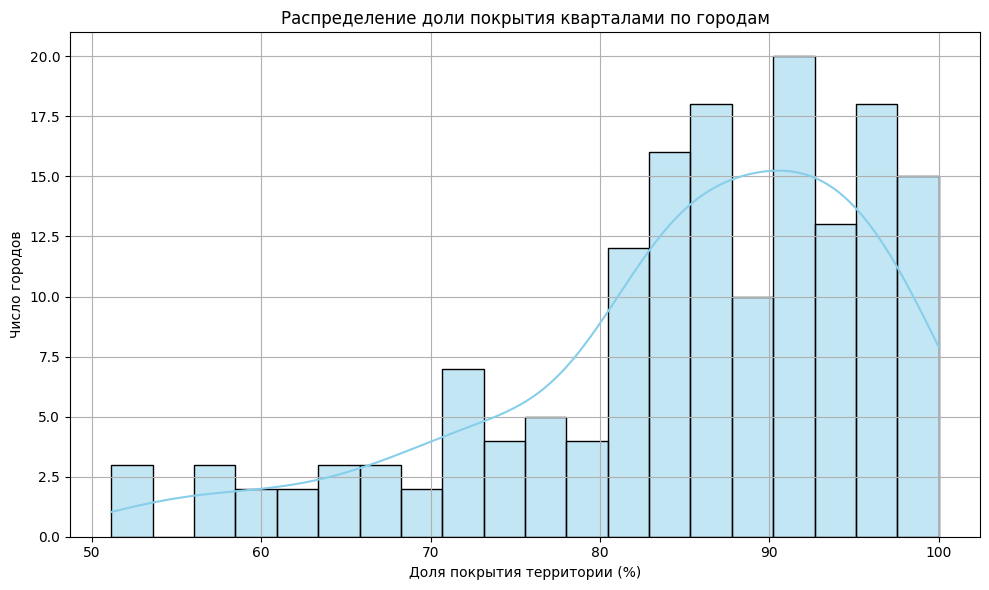

In [3]:
# Собираем метаданные по городам
city_metadata = []

for gdf in city_gdfs_with_coverage:
    city = gdf['city'].iloc[0]
    country = gdf['country'].iloc[0]
    covered_ratio = gdf['covered_area_ratio'].iloc[0]
    total_city_area = gdf['city_boundary_area_m2'].iloc[0]
    total_block_area = gdf['area_m2'].sum()
    
    city_metadata.append({
        'city': city,
        'country': country,
        'covered_ratio': covered_ratio,  # доля покрытия
        'total_city_area_km2': total_city_area / 1e6,  # м² → км²
        'total_block_area_km2': total_block_area / 1e6
    })

# Преобразуем в DataFrame
city_coverage_df = pd.DataFrame(city_metadata)

# Гистограмма доли покрытия
plt.figure(figsize=(10, 6))
sns.histplot(city_coverage_df['covered_ratio'] * 100, bins=20, kde=True, color='skyblue')
plt.title('Распределение доли покрытия кварталами по городам')
plt.xlabel('Доля покрытия территории (%)')
plt.ylabel('Число городов')
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# Собираем результаты
city_landuse_coverage = []

for gdf in city_gdfs_with_coverage:
    gdf['land_use_name'] = gdf['land_use'].apply(lambda x: x.value)
    # Группируем по land_use и суммируем area_pct_of_city
    coverage_by_type = (
        gdf.groupby('land_use_name')['area_pct_of_city']
        .sum()
        .reset_index()
        .rename(columns={'area_pct_of_city': 'coverage_pct'})
    )
    
    # Добавляем информацию о городе
    city_name = gdf['city'].iloc[0]
    country_name = gdf['country'].iloc[0]
    total_covered_ratio = gdf['covered_area_ratio'].iloc[0]  # доля покрытия (1 - uncovered)
    
    coverage_by_type['city'] = city_name
    coverage_by_type['country'] = country_name
    coverage_by_type['total_covered_pct'] = total_covered_ratio * 100  # в процентах
    
    city_landuse_coverage.append(coverage_by_type)

# Объединяем всё в один DataFrame
all_coverage_df = pd.concat(city_landuse_coverage, ignore_index=True)

# Переводим в удобный формат
all_coverage_df = all_coverage_df[['city', 'country', 'land_use_name', 'coverage_pct', 'total_covered_pct']]
all_coverage_df = all_coverage_df.round(3)

print("✅ Готово! Покрытие по типам землепользования для всех городов:")
all_coverage_df.head(10)

✅ Готово! Покрытие по типам землепользования для всех городов:


,city,country,land_use_name,coverage_pct,total_covered_pct
0,Abakan,Russia,agriculture,32.721,86.617
1,Abakan,Russia,business,0.999,86.617
2,Abakan,Russia,industrial,12.821,86.617
3,Abakan,Russia,recreation,1.882,86.617
4,Abakan,Russia,residential,32.211,86.617
5,Abakan,Russia,special,2.335,86.617
6,Abakan,Russia,transport,3.649,86.617
7,Achinsk,Russia,agriculture,19.296,69.298
8,Achinsk,Russia,business,0.184,69.298
9,Achinsk,Russia,industrial,11.686,69.298


In [5]:
# Шаг 1: Найдём все города, где residential > 60%
cities_to_remove = all_coverage_df[
    (all_coverage_df['land_use_name'].str.upper() == 'RESIDENTIAL') & (all_coverage_df['coverage_pct'] > 50) |
    (all_coverage_df['land_use_name'].str.upper() == 'RESIDENTIAL') & (all_coverage_df['coverage_pct'] < 10) |
    (all_coverage_df['land_use_name'].str.upper() == 'AGRICULTURE') & (all_coverage_df['coverage_pct'] > 40) |
    (all_coverage_df['total_covered_pct'] < 80) 
]['city']

# Преобразуем в множество для быстрого поиска
cities_to_remove_set = set(cities_to_remove)

print(f"❌ Города с RESIDENTIAL > 60% (будут удалены): {len(cities_to_remove_set)}")

❌ Города с RESIDENTIAL > 60% (будут удалены): 78


In [6]:
# Удаляем ВСЕ строки, где city в списке cities_to_remove_set
all_coverage_df_filter = all_coverage_df[
    ~all_coverage_df['city'].isin(cities_to_remove_set)
].copy()

print(f"✅ Осталось городов: {all_coverage_df_filter['city'].nunique()}")

UNIQUE_CITIES = all_coverage_df_filter['city'].unique()

✅ Осталось городов: 82


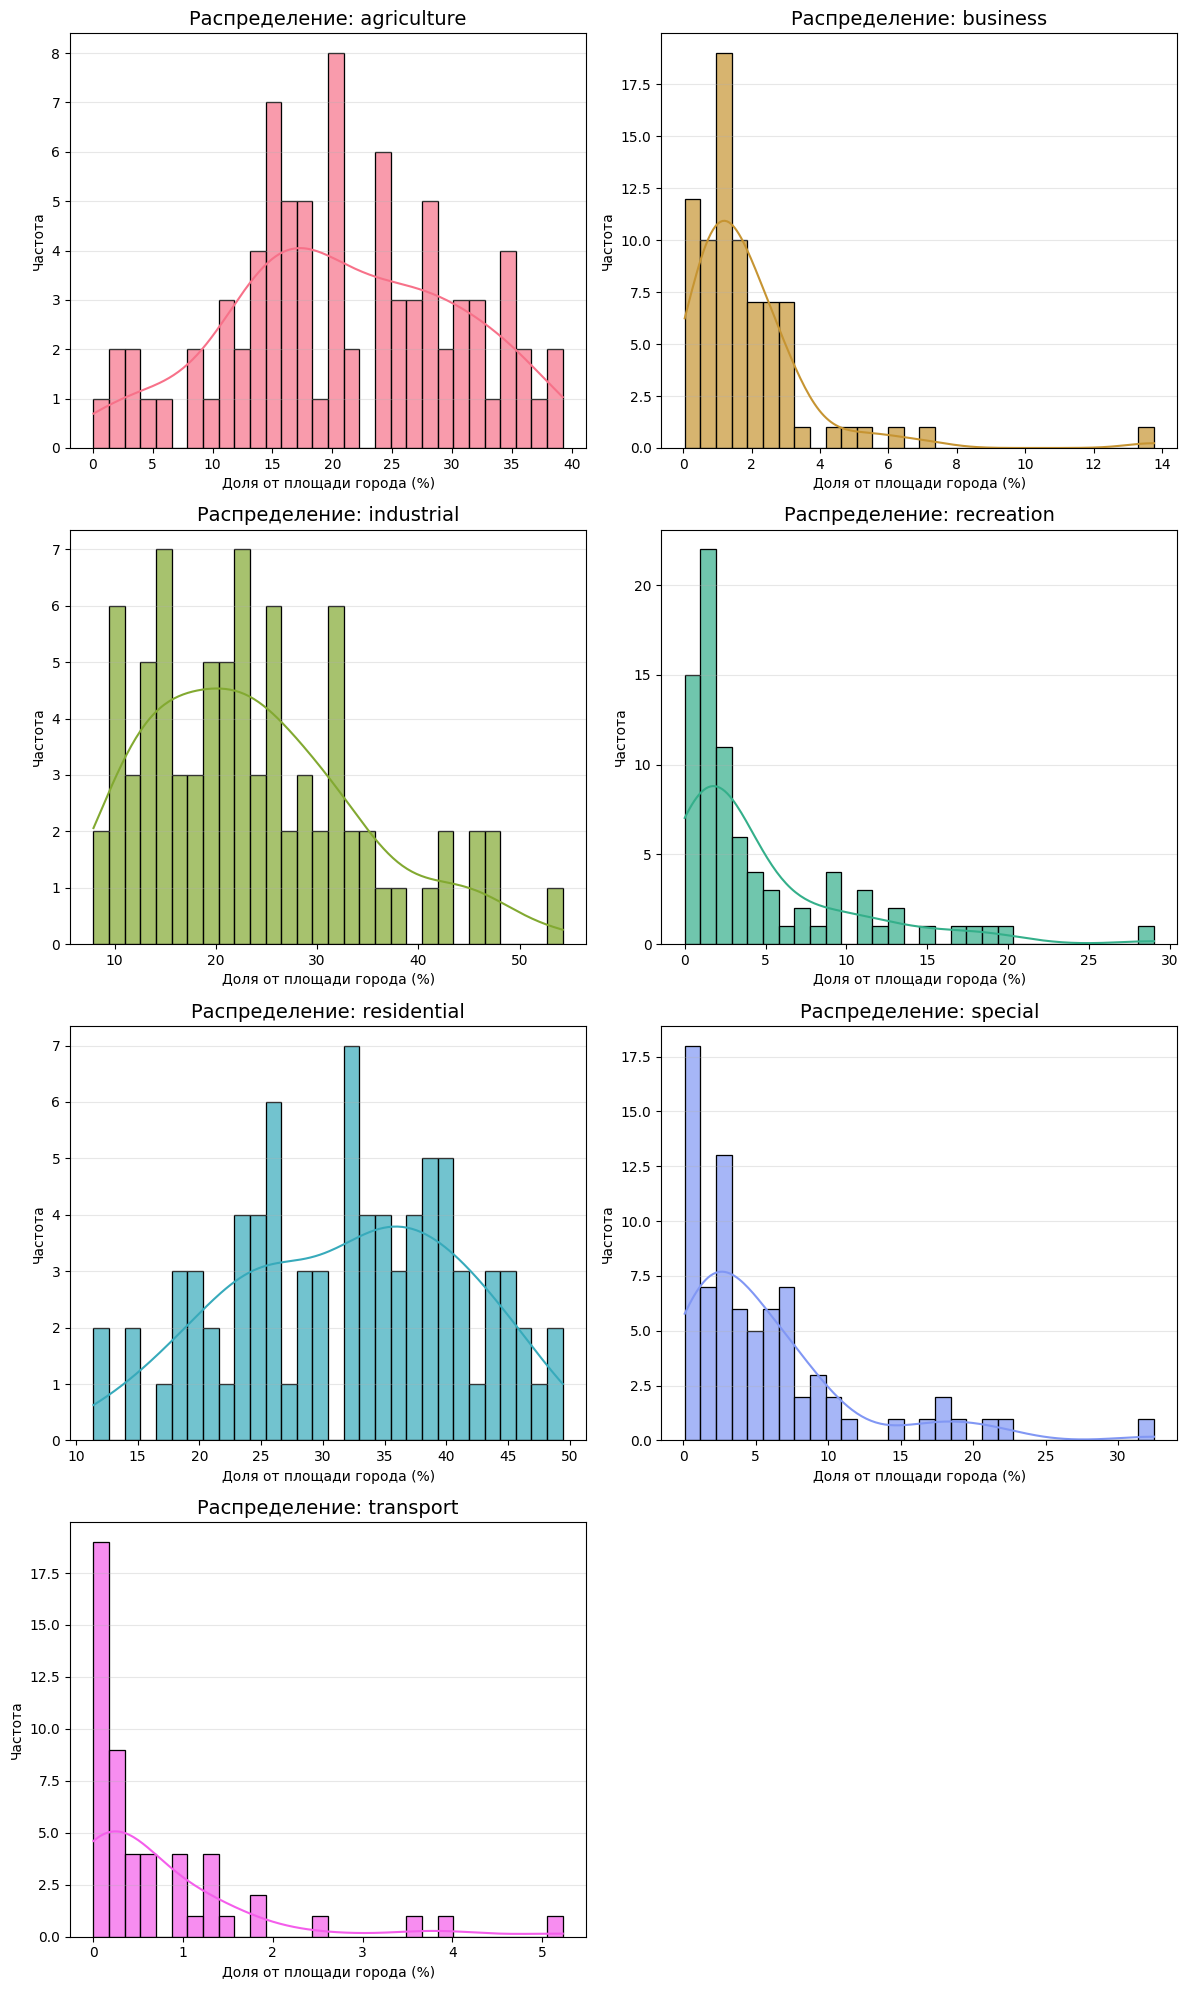

In [7]:
# Получаем список уникальных типов землепользования
land_use_types = all_coverage_df_filter['land_use_name'].unique()
n_types = len(land_use_types)

# Настройка сетки графиков
cols = 2
rows = (n_types + cols - 1) // cols  # округление вверх
fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
axes = axes.flatten() if n_types > 1 else [axes]

# Цвета — можно использовать палитру
colors = sns.color_palette("husl", n_types)

for idx, land_use in enumerate(land_use_types):
    ax = axes[idx]
    data = all_coverage_df_filter[all_coverage_df_filter['land_use_name'] == land_use]['coverage_pct'].dropna()
    
    if len(data) == 0:
        ax.text(0.5, 0.5, 'Нет данных', transform=ax.transAxes, ha='center', va='center')
        ax.set_title(f"{land_use} (пусто)")
    else:
        # Гистограмма + KDE
        sns.histplot(data, bins=30, kde=True, ax=ax, color=colors[idx], alpha=0.7)
        ax.set_title(f"Распределение: {land_use}", fontsize=14)
        ax.set_xlabel('Доля от площади города (%)')
        ax.set_ylabel('Частота')
        ax.grid(True, axis='y', alpha=0.3)

# Скрыть лишние подграфики
for idx in range(n_types, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
from blocksnet.analysis.land_use.prediction.core import str_to_land_use, land_use_to_category, category_to_index
from blocksnet.analysis.land_use.prediction.schemas import BlocksInputSchema
import pandas as pd

def normalize_and_filter(data):
    if isinstance(data, (list, tuple)):
        out = []
        for g in data:
            gi = BlocksInputSchema(g)
            if 'land_use' in gi:
                gi['category'] = gi['land_use'].map(str_to_land_use).map(land_use_to_category)
            gi = gi[gi['category'].map(category_to_index).notna()]
            if not gi.empty:
                gi['geometry'] = gi['geometry'].buffer(0)
                out.append(gi)
        return out
    else:
        g = BlocksInputSchema(data)
        if 'land_use' in g:
            g['category'] = g['land_use'].map(str_to_land_use).map(land_use_to_category)
        return g[g['category'].map(category_to_index).notna()]

blocks_gdf = normalize_and_filter(blocks_gdf)
spb_test = normalize_and_filter(spb_test)
spb_test = spb_test[0]

In [50]:
import geopandas as gpd
from copy import deepcopy

# Маппинг 7 → 2
mapping_7_to_2 = {
    "INDUSTRIAL": "NOT_LIVING",
    "RECREATION": "NOT_LIVING",
    "BUSINESS": "NOT_LIVING",
    "RESIDENTIAL": "LIVING",
    "AGRICULTURE": "NOT_LIVING",
    "SPECIAL": "NOT_LIVING",
    "TRANSPORT": "NOT_LIVING"
}

mapping_7_to_3 = {
    "INDUSTRIAL": "LARGEAREA",
    "RECREATION": "LARGEAREA",
    "BUSINESS": "MIXEDUSE",
    "RESIDENTIAL": "MIXEDUSE",
    "AGRICULTURE": "LARGEAREA",
    "SPECIAL": "ENGINEERING",
    "TRANSPORT": "ENGINEERING"
}

mapping_7_to_4 = {
    "INDUSTRIAL": "INDUSTRIAL",
    "RECREATION": "RECREATION",
    "BUSINESS": "MIXEDUSE",
    "RESIDENTIAL": "MIXEDUSE",
    "AGRICULTURE": "RECREATION",
    "SPECIAL": "ENGINEERING",
    "TRANSPORT": "ENGINEERING"
}

mapping_7_to_7 = {
    "INDUSTRIAL": "INDUSTRIAL",
    "RECREATION": "RECREATION",
    "BUSINESS": "BUSINESS",
    "RESIDENTIAL": "RESIDENTIAL",
    "AGRICULTURE": "AGRICULTURE",
    "SPECIAL": "SPECIAL",
    "TRANSPORT": "TRANSPORT"
}

# Создаём новый список GeoDataFrame'ов с бинарными метками
city_gdfs_binary = []

for gdf_city in blocks_gdf:  # ваш list(gdf) по городам
    # Глубокая копия, чтобы не изменять оригинал
    gdf_bin = deepcopy(gdf_city)
    
    # Предполагаем, что категория хранится в колонке 'CATEGORY' как строка
    # Если это Enum — конвертируем в строку
    if gdf_bin['land_use'].dtype == 'object':
        cat_str = gdf_bin['land_use'].astype(str).str.split('.').str[-1]  # если Enum: 'land_use.RESIDENTIAL' → 'RESIDENTIAL'
    else:
        cat_str = gdf_bin['land_use'].apply(lambda x: x.value if hasattr(x, 'value') else x)
    
    # Маппинг в бинарный класс
    gdf_bin['target'] = cat_str.map(mapping_7_to_2)
    
    # Опционально: сохраняем оригинальную категорию
    # gdf_bin['land_use_ORIGINAL'] = cat_str
    
    city_gdfs_binary.append(gdf_bin)

spb_test['target'] = spb_test['land_use'].str.upper().map(mapping_7_to_2)
kem_test['target'] = kem_test['land_use'].str.upper().map(mapping_7_to_2)

spb_test.dropna(inplace=True)
kem_test.dropna(inplace=True)

spb_test.reset_index(drop=True, inplace=True)
kem_test.reset_index(drop=True, inplace=True)

In [51]:
def mask_random_targets(
    gdf,
    target_col="target",
    min_frac=0.1,
    max_frac=0.7,
    random_state=None
):
    """
    Случайно заменяет от min_frac до max_frac значений target_col на None.
    Для каждого GeoDataFrame доля выбирается случайно.
    """
    gdf = gdf.copy()
    rng = np.random.default_rng(random_state)
    frac = rng.uniform(min_frac, max_frac)
    mask = rng.random(len(gdf)) < frac
    gdf.loc[mask, target_col] = None
    gdf.attrs["masked_frac"] = frac
    return gdf

# --- применяем к списку городов ---
city_gdfs_binary_mask = [
    mask_random_targets(gdf, target_col="target", random_state=i)
    for i, gdf in enumerate(tqdm(city_gdfs_binary, desc="Masking targets"))
]

spb_test_mask = mask_random_targets(spb_test, target_col="target", random_state=42)
kem_test_mask = mask_random_targets(kem_test, target_col="target", random_state=42)

# можно вывести сводку
for i, gdf in enumerate(city_gdfs_binary_mask[:10]):
    frac = gdf.attrs.get("masked_frac", None)
    if frac is not None:
        print(f"Город {i+1:>3}: скрыто {frac*100:.1f}% меток (≈ {gdf['target'].isna().sum():>3} из {len(gdf):>4})")

print(f"Город СПб: скрыто {spb_test_mask.attrs.get('masked_frac', None)*100:.1f}% меток (≈ {spb_test_mask['target'].isna().sum():>3} из {len(spb_test_mask):>4})")
print(f"Город Кемерово: скрыто {kem_test_mask.attrs.get('masked_frac', None)*100:.1f}% меток (≈ {kem_test_mask['target'].isna().sum():>3} из {len(kem_test_mask):>4})")

Masking targets:   0%|          | 0/160 [00:00<?, ?it/s]

Город   1: скрыто 48.2% меток (≈ 455 из 1002)
Город   2: скрыто 40.7% меток (≈ 165 из  385)
Город   3: скрыто 25.7% меток (≈ 168 из  614)
Город   4: скрыто 15.1% меток (≈ 131 из  806)
Город   5: скрыто 66.6% меток (≈ 172 из  289)
Город   6: скрыто 58.3% меток (≈ 230 из  372)
Город   7: скрыто 42.3% меток (≈ 141 из  340)
Город   8: скрыто 47.5% меток (≈ 788 из 1615)
Город   9: скрыто 29.6% меток (≈  85 из  278)
Город  10: скрыто 62.2% меток (≈ 496 из  796)
Город СПб: скрыто 56.4% меток (≈ 5268 из 9249)
Город Кемерово: скрыто 56.4% меток (≈ 1082 из 1918)


In [61]:
import networkx as nx
from tqdm.notebook import tqdm
from scipy.spatial.distance import cdist


def _mrr_metrics(geom):
    """
    Метрики минимального повёрнутого прямоугольника (MRR) для полигона:
    ширина, высота, площадь и аспект (width/height, >=1).
    Возвращает (width, height, area, aspect_ratio).
    """
    try:
        mrr = geom.minimum_rotated_rectangle
        coords = np.array(mrr.exterior.coords)
        # четыре уникальные длины сторон
        edges = np.sqrt(((coords[1:] - coords[:-1])**2).sum(axis=1))
        # в MRR есть две пары равных сторон; берём две уникальные длины
        lengths = np.sort(np.unique(np.round(edges, 12)))
        if len(lengths) >= 2:
            width, height = float(lengths[-1]), float(lengths[-2])
        elif len(lengths) == 1:
            width, height = float(lengths[0]), float(lengths[0])
        else:
            width = height = 0.0
        area = float(mrr.area)
        w, h = (width, height) if width >= height else (height, width)
        aspect = (w / (h + 1e-12)) if (w > 0 and h > 0) else 1.0
        return w, h, area, aspect
    except Exception:
        return 0.0, 0.0, 0.0, 1.0

def add_spatial_features(
    gdf: gpd.GeoDataFrame,
    target_col: str = "target",
    radii=(100, 500, 1000),
    batch_size: int = 500
) -> gpd.GeoDataFrame:
    """
    Признаки для классификации типа землепользования:
      • геометрия формы (в т.ч. фрактальность/прямоугольность/ориентация MRR),
      • пространственные признаки соседства в радиусах (100, 500, 1000 м),
      • локальные метрические признаки (межквартальные расстояния),
      • графовые признаки по соседству через буфер 10 м (networkx).
    """
    gdf = gdf.copy()
    utm_crs = gdf.estimate_utm_crs()
    gdf = gdf.to_crs(utm_crs)

    # --- Геометрические признаки ---
    gdf["area"] = gdf.geometry.area
    gdf["perimeter"] = gdf.geometry.length
    # компактность (округлость)
    gdf["compactness"] = (4 * np.pi * gdf["area"]) / (gdf["perimeter"]**2 + 1e-12)
    # выпуклая оболочка и «заполненность»
    gdf["convex_hull_area"] = gdf.geometry.convex_hull.area
    gdf["solidity"] = gdf["area"] / (gdf["convex_hull_area"] + 1e-12)

    # ограничивающий bbox
    bounds = gdf.geometry.bounds
    gdf["bbox_width"]  = bounds["maxx"] - bounds["minx"]
    gdf["bbox_height"] = bounds["maxy"] - bounds["miny"]
    gdf["elongation"] = np.where(
        gdf["bbox_height"] > 0,
        gdf["bbox_width"] / (gdf["bbox_height"] + 1e-12),
        1.0
    )

    # --- Форма по минимальному повёрнутому прямоугольнику (MRR) ---
    mrr_vals = gdf.geometry.apply(_mrr_metrics)
    gdf["mrr_width"]        = [t[0] for t in mrr_vals]
    gdf["mrr_height"]       = [t[1] for t in mrr_vals]
    gdf["mrr_area"]         = [t[2] for t in mrr_vals]
    gdf["mrr_aspect_ratio"] = [t[3] for t in mrr_vals]
    # прямоугольность: насколько форма заполняет MRR
    gdf["rectangularity_index"] = gdf["area"] / (gdf["mrr_area"] + 1e-12)
    # индекс сложности формы (Miller): чем выше, тем граница «извилистее»
    gdf["shape_index"] = 0.25 * gdf["perimeter"] / np.sqrt(gdf["area"] + 1e-12)
    # приближённая фрактальная размерность границы (масштабно-инвариантная эвристика)
    # FD ~ 2 * log(P/4) / log(A)
    gdf["fractal_dimension"] = (
        2.0 * np.log((gdf["perimeter"] + 1e-12) / 4.0) / np.log(gdf["area"] + 1e-12)
    ).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0, upper=2.5)

    # --- Пространственные признаки для нескольких радиусов ---
    for radius in radii:
        buffers = gdf.geometry.buffer(radius)
        right = gpd.GeoDataFrame(
            gdf[[target_col, "area"]].copy(),
            geometry=buffers,
            crs=gdf.crs
        )

        joined = gpd.sjoin(
            gdf[[target_col, "geometry", "area"]],
            right,
            how="left",
            predicate="intersects",
            lsuffix="A",
            rsuffix="B",
        ).reset_index()

        left_index = "index"
        right_index = "index_B"
        if left_index not in joined.columns and joined.index.name:
            joined = joined.reset_index(names="index_left")
            left_index = "index_left"

        joined = joined[joined[left_index] != joined[right_index]]

        # --- обработка пропусков ---
        joined[f"{target_col}_B"] = joined[f"{target_col}_B"].fillna("__none__")

        # базовые агрегаты
        n_neighbors = joined.groupby(left_index).size()
        avg_area_neighbors = joined.groupby(left_index)["area_B"].mean()

        # количество и площадь соседей без категории
        none_mask = joined[f"{target_col}_B"] == "__none__"
        n_neighbors_none = none_mask.groupby(joined[left_index]).sum()
        avg_area_none = (
            joined.loc[none_mask].groupby(left_index)["area_B"].mean()
            if none_mask.any()
            else pd.Series(dtype=float)
        )

        gdf[f"n_neighbors_{radius}m"] = gdf.index.map(n_neighbors).fillna(0).astype(int)
        gdf[f"avg_area_neighbors_{radius}m"] = gdf.index.map(avg_area_neighbors).fillna(0.0)
        gdf[f"n_neighbors_none_{radius}m"] = gdf.index.map(n_neighbors_none).fillna(0).astype(int)
        gdf[f"avg_area_neighbors_none_{radius}m"] = gdf.index.map(avg_area_none).fillna(0.0)

        # --- распределение по классам (без None) ---
        pct_by_class = (
            joined[joined[f"{target_col}_B"] != "__none__"]
            .groupby([left_index, f"{target_col}_B"])
            .size()
            .unstack(fill_value=0)
        )
        pct_by_class = pct_by_class.div(pct_by_class.sum(axis=1), axis=0)

        for cls in pct_by_class.columns:
            gdf[f"pct_neighbor_{str(cls).lower()}_{radius}m"] = (
                gdf.index.map(pct_by_class[cls]).fillna(0.0)
            )

    # --- Локальные метрические признаки (cdist, representative_point) ---
    reps = gdf.geometry.representative_point()
    coords = np.column_stack((reps.x.values, reps.y.values)).astype(float)
    n = len(coords)

    # создаём заготовки под метрики
    median_dist = np.zeros(n)
    mean_k3_dist = np.zeros(n)
    mean_k5_dist = np.zeros(n)
    mean_k7_dist = np.zeros(n)
    mean_k10_dist = np.zeros(n)

    if n > 1:
        for i in range(0, n, batch_size):
            batch = coords[i:i + batch_size]
            dist_block = cdist(batch, coords)
            # маскируем «самого себя»
            row_idx, col_idx = np.indices(dist_block.shape)
            self_mask = (row_idx + i == col_idx)
            dist_block[self_mask] = np.nan

            # медианное расстояние до всех остальных
            median_dist[i:i + batch_size] = np.nanmedian(dist_block, axis=1)

            # сортируем и берём разные k
            sorted_dist = np.sort(dist_block, axis=1)
            for k, arr in zip(
                [3, 5, 7, 10],
                [mean_k3_dist, mean_k5_dist, mean_k7_dist, mean_k10_dist]
            ):
                k_lim = min(k, sorted_dist.shape[1] - 1)
                arr[i:i + batch_size] = np.nanmean(sorted_dist[:, :k_lim], axis=1)

    # добавляем в GeoDataFrame
    gdf["median_dist"] = median_dist
    gdf["mean_k3_dist"] = mean_k3_dist
    gdf["mean_k5_dist"] = mean_k5_dist
    gdf["mean_k7_dist"] = mean_k7_dist
    gdf["mean_k10_dist"] = mean_k10_dist

    # --- Граф по пересечениям с буфером 10 м (networkx) ---
    # левая — исходная геометрия, правая — буфер 10 м
    buf10 = gdf.geometry.buffer(10.0)
    right10 = gpd.GeoDataFrame(
        index=gdf.index,
        geometry=buf10,
        crs=gdf.crs
    )
    pairs = gpd.sjoin(
        gdf[["geometry"]], right10,
        how="left", predicate="intersects",
        lsuffix="L", rsuffix="R"
    ).reset_index()

    li = "index"
    ri = "index_R"
    if li not in pairs.columns and pairs.index.name:
        pairs = pairs.reset_index(names="index_left")
        li = "index_left"

    # удаляем самосоединения
    pairs = pairs[pairs[li] != pairs[ri]]
    # формируем уникальные неориентированные рёбра
    edges = {(int(a), int(b)) if a < b else (int(b), int(a))
             for a, b in zip(pairs[li], pairs[ri])}
    G = nx.Graph()
    G.add_nodes_from(gdf.index.astype(int).tolist())
    G.add_edges_from(edges)

    # степень
    deg = dict(G.degree())
    gdf["deg_10m"] = gdf.index.map(deg).fillna(0).astype(int)

    # кластерный коэффициент
    clust = nx.clustering(G)
    gdf["clust_10m"] = gdf.index.map(clust).fillna(0.0)

    # средняя степень соседей
    andeg = nx.average_neighbor_degree(G)
    gdf["avg_n_deg_10m"] = gdf.index.map(andeg).fillna(0.0)

    # компоненты связности
    comp_id = {}
    comp_size = {}
    for cid, comp_nodes in enumerate(nx.connected_components(G), start=1):
        size = len(comp_nodes)
        for u in comp_nodes:
            comp_id[u] = cid
            comp_size[u] = size
    gdf["component_id_10m"]   = gdf.index.map(comp_id).fillna(0).astype(int)
    gdf["component_size_10m"] = gdf.index.map(comp_size).fillna(1).astype(int)

    # PageRank (быстрый, устойчивый)
    try:
        pr = nx.pagerank(G, alpha=0.85, max_iter=200)
    except Exception:
        pr = {u: 0.0 for u in G.nodes()}
    gdf["pagerank_10m"] = gdf.index.map(pr).fillna(0.0)

    # --- Завершение ---
    gdf = gdf.to_crs(4326)

    feature_cols = [
        # геометрия формы
        "area", "perimeter", "compactness", "solidity",
        "bbox_width", "bbox_height", "elongation",
        "mrr_width", "mrr_height", "mrr_area", "mrr_aspect_ratio",
        "rectangularity_index", "shape_index", "fractal_dimension",
        # локальные дистанции
        "median_dist", "mean_k3_dist", "mean_k5_dist", "mean_k7_dist", "mean_k10_dist",
        # графовые по 10 м
        "deg_10m", "clust_10m", "avg_n_deg_10m",
        "component_id_10m", "component_size_10m", "pagerank_10m",
    ]
    # мультирадиусные соседства и доли по классам
    feature_cols += [c for c in gdf.columns if c.startswith(("n_neighbors_", "avg_area_neighbors_", "pct_neighbor_"))]

    return gdf[feature_cols + [target_col, "geometry"]]


city_gdfs_with_features = [
    add_spatial_features(gdf) for gdf in tqdm(city_gdfs_binary_mask)
]

test_gdf_spb = add_spatial_features(spb_test_mask)
test_gdf_kem = add_spatial_features(kem_test_mask)

  0%|          | 0/160 [00:00<?, ?it/s]

In [62]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
import pandas as pd
import numpy as np

# --- 1. Объединение всех городов ---
train_combined = pd.concat([
    gdf.drop(columns=['geometry']) for gdf in city_gdfs_with_features
], ignore_index=True)

# --- 2. Автоматическое определение числовых признаков ---
# Оставляем только колонки с числовыми типами (int, float), исключая целевую
feature_cols = train_combined.select_dtypes(include=[np.number]).columns.tolist()


print("Используемые признаки:", feature_cols)

# --- 3. X и y ---
X_train = train_combined[feature_cols].values
y_train_str = pd.concat([
    gdf.drop(columns=['geometry']) for gdf in city_gdfs_binary
], ignore_index=True)['target']  # 'LIVING' или 'NOT_LIVING'

# Кодируем метки
le = LabelEncoder()
y_train = le.fit_transform(y_train_str)
print("Классы:", dict(zip(le.classes_, le.transform(le.classes_))))  # например: {'LIVING': 0, 'NOT_LIVING': 1}

# --- 4. Нормализация ---
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

# --- 5. Подготовка тестовых данных ---
# Извлекаем X_test
X_test_spb = scaler.transform(test_gdf_spb[feature_cols].values)
X_test_kem = scaler.transform(test_gdf_kem[feature_cols].values)

# Преобразуем y_test
if 'target' in spb_test.columns and 'target' in kem_test.columns:
    y_test_spb = le.transform(spb_test['target'].values)
    y_test_kem = le.transform(kem_test['target'].values)
else:
    raise ValueError("Тестовый DataFrame должен содержать колонку 'target' для оценки")

print(f"Размер X_train: {X_train_scaled.shape}")
print(f"Размер X_test SPb: {X_test_spb.shape}")
print(f"Размер X_test Kem: {X_test_kem.shape}")
print(f"Количество признаков: {len(feature_cols)}")

Используемые признаки: ['area', 'perimeter', 'compactness', 'solidity', 'bbox_width', 'bbox_height', 'elongation', 'mrr_width', 'mrr_height', 'mrr_area', 'mrr_aspect_ratio', 'rectangularity_index', 'shape_index', 'fractal_dimension', 'median_dist', 'mean_k3_dist', 'mean_k5_dist', 'mean_k7_dist', 'mean_k10_dist', 'deg_10m', 'clust_10m', 'avg_n_deg_10m', 'component_id_10m', 'component_size_10m', 'pagerank_10m', 'n_neighbors_100m', 'avg_area_neighbors_100m', 'n_neighbors_none_100m', 'avg_area_neighbors_none_100m', 'pct_neighbor_living_100m', 'pct_neighbor_not_living_100m', 'n_neighbors_500m', 'avg_area_neighbors_500m', 'n_neighbors_none_500m', 'avg_area_neighbors_none_500m', 'pct_neighbor_living_500m', 'pct_neighbor_not_living_500m', 'n_neighbors_1000m', 'avg_area_neighbors_1000m', 'n_neighbors_none_1000m', 'avg_area_neighbors_none_1000m', 'pct_neighbor_living_1000m', 'pct_neighbor_not_living_1000m']
Классы: {'LIVING': np.int64(0), 'NOT_LIVING': np.int64(1)}
Размер X_train: (163285, 43)
Р

In [63]:
# Импорты моделей
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import time

from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
# Метрики и утилиты
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# --- Список моделей ---
models = []

# Случайный лес (ограничим глубину и деревья)
models.append(('RFast', RandomForestClassifier(
    n_estimators=50,           # меньше деревьев
    max_depth=8,               # ограничим глубину
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)))

# LightGBM с early stopping и малым числом деревьев
models.append(('LGBM-Fast', LGBMClassifier(
    n_estimators=100,          # уменьшаем число деревьев
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    verbose=-1,
    n_jobs=-1,
    random_state=42
)))

# XGBoost (ускоренный)
models.append(('XGB-Fast', XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)))

# Настройка CV (можно уменьшить до 3 фолдов для скорости!)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # было 5 → стало 3 (снижает время на 40%)

scoring = 'f1_macro'
results = []
names = []

print("🚀 Старт сравнения моделей\n")
print(f"{'Модель':<12} | {'F1-Macro':<10} | {'Время (сек)':<12}")
print("-" * 45)

# Оборачиваем модели в tqdm для прогресс-бара
for name, model in models:
    start_time = time.time()
    try:
        # Кросс-валидация
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        mean_f1 = cv_scores.mean()
        std_f1 = cv_scores.std()
        
        elapsed = time.time() - start_time
        
        results.append((name, mean_f1, std_f1, elapsed))
        names.append(name)
        
        # Вывод строки сразу
        print(f"{name:<12} | {mean_f1:.4f}     | {elapsed:8.1f}")
        
    except Exception as e:
        elapsed = time.time() - start_time
        print(f"{name:<12} | Ошибка      | {elapsed:8.1f} | {str(e)[:50]}")
        continue

# Таблица результатов
df_results = pd.DataFrame(results, columns=['Model', 'F1-Macro', 'Std', 'Time (s)'])
df_results.sort_values(by='F1-Macro', ascending=False, inplace=True)

print("\n" + "="*50)
print("🏆 Рейтинг моделей (по F1-Macro)")
print("="*50)
print(df_results[['Model', 'F1-Macro', 'Std', 'Time (s)']].round(4).to_string(index=False))

best_model_name = df_results.iloc[0]['Model']
print(f"\n✅ Лучшая модель: {best_model_name}")

🚀 Старт сравнения моделей

Модель       | F1-Macro   | Время (сек) 
---------------------------------------------
RFast        | 0.8896     |     12.8
LGBM-Fast    | 0.8955     |      5.8
XGB-Fast     | 0.8974     |      6.7

🏆 Рейтинг моделей (по F1-Macro)
    Model  F1-Macro    Std  Time (s)
 XGB-Fast    0.8974 0.0016    6.7186
LGBM-Fast    0.8955 0.0010    5.7767
    RFast    0.8896 0.0017   12.8496

✅ Лучшая модель: XGB-Fast


In [64]:
# --- Определяем лучшие базовые модели ---
voting_models = [
    ('XGB', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss',
        use_label_encoder=False,
        n_jobs=-1,
        random_state=42
    )),
    ('LGBM', LGBMClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        class_weight='balanced',
        verbose=-1,
        n_jobs=-1,
        random_state=42
    )),
    ('RF', RandomForestClassifier(
        n_estimators=50,
        max_depth=8,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
]

# --- Инициализация VotingClassifier ---
voting = VotingClassifier(
    estimators=voting_models,
    voting='soft',     # используем вероятности, а не метки (лучше для несбалансированных данных)
    weights=[1.8, 1.5, 1], # большее влияние лучшей модели XGB
    n_jobs=-1
)

# --- Кросс-валидация ---
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = 'f1_macro'

print("🚀 Оценка Voting-модели\n")
start_time = time.time()

cv_scores = cross_val_score(voting, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)

elapsed = time.time() - start_time
mean_f1 = np.mean(cv_scores)
std_f1 = np.std(cv_scores)

print(f"Voting (soft) | F1-Macro: {mean_f1:.4f} ± {std_f1:.4f} | Время: {elapsed:.1f} сек")

# --- Обучение на всех данных (для финальной модели) ---
voting.fit(X_train_scaled, y_train)

# Прогноз
y_pred_spb = voting.predict(X_test_spb)
y_pred_kem = voting.predict(X_test_kem)

🚀 Оценка Voting-модели

Voting (soft) | F1-Macro: 0.8978 ± 0.0016 | Время: 29.5 сек


In [65]:
test_gdf_spb['predict'] = le.inverse_transform(y_pred_spb)
test_gdf_kem['predict'] = le.inverse_transform(y_pred_kem)


Отчёт по тестовой выборке Санкт-Петербурга:
              precision    recall  f1-score   support

      LIVING       0.78      0.87      0.82      4993
  NOT_LIVING       0.82      0.71      0.76      4256

    accuracy                           0.79      9249
   macro avg       0.80      0.79      0.79      9249
weighted avg       0.80      0.79      0.79      9249


Отчёт по тестовой выборке Кемерово:
              precision    recall  f1-score   support

      LIVING       0.81      0.91      0.86      1300
  NOT_LIVING       0.76      0.56      0.65       618

    accuracy                           0.80      1918
   macro avg       0.79      0.74      0.75      1918
weighted avg       0.80      0.80      0.79      1918



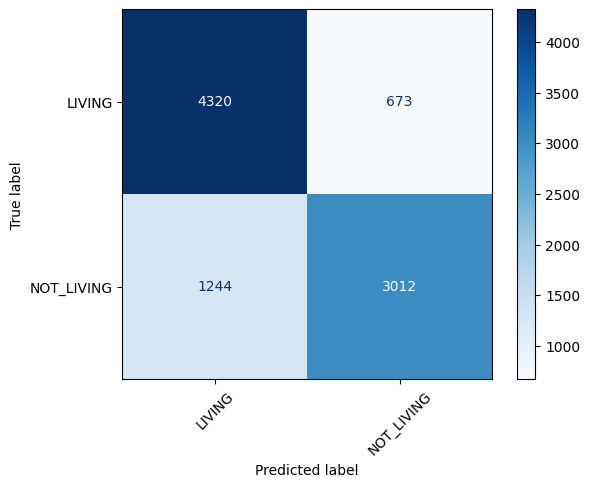

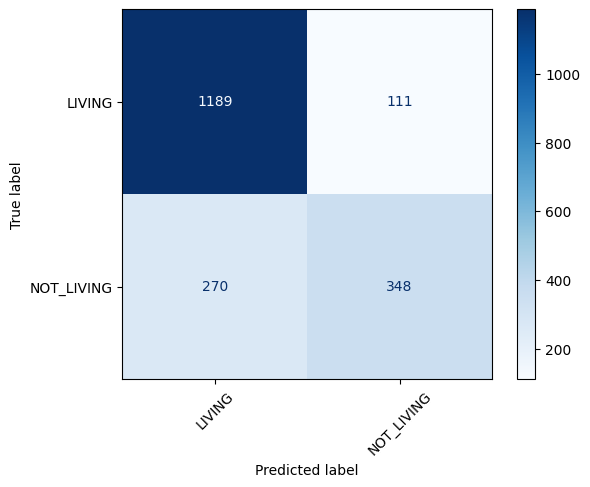

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\nОтчёт по тестовой выборке Санкт-Петербурга:")
print(classification_report(y_test_spb, y_pred_spb, target_names=le.classes_))


cm = confusion_matrix(y_test_spb, y_pred_spb, labels=range(len(le.classes_)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)

print("\nОтчёт по тестовой выборке Кемерово:")
print(classification_report(y_test_kem, y_pred_kem, target_names=le.classes_))


cm = confusion_matrix(y_test_kem, y_pred_kem, labels=range(len(le.classes_)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)


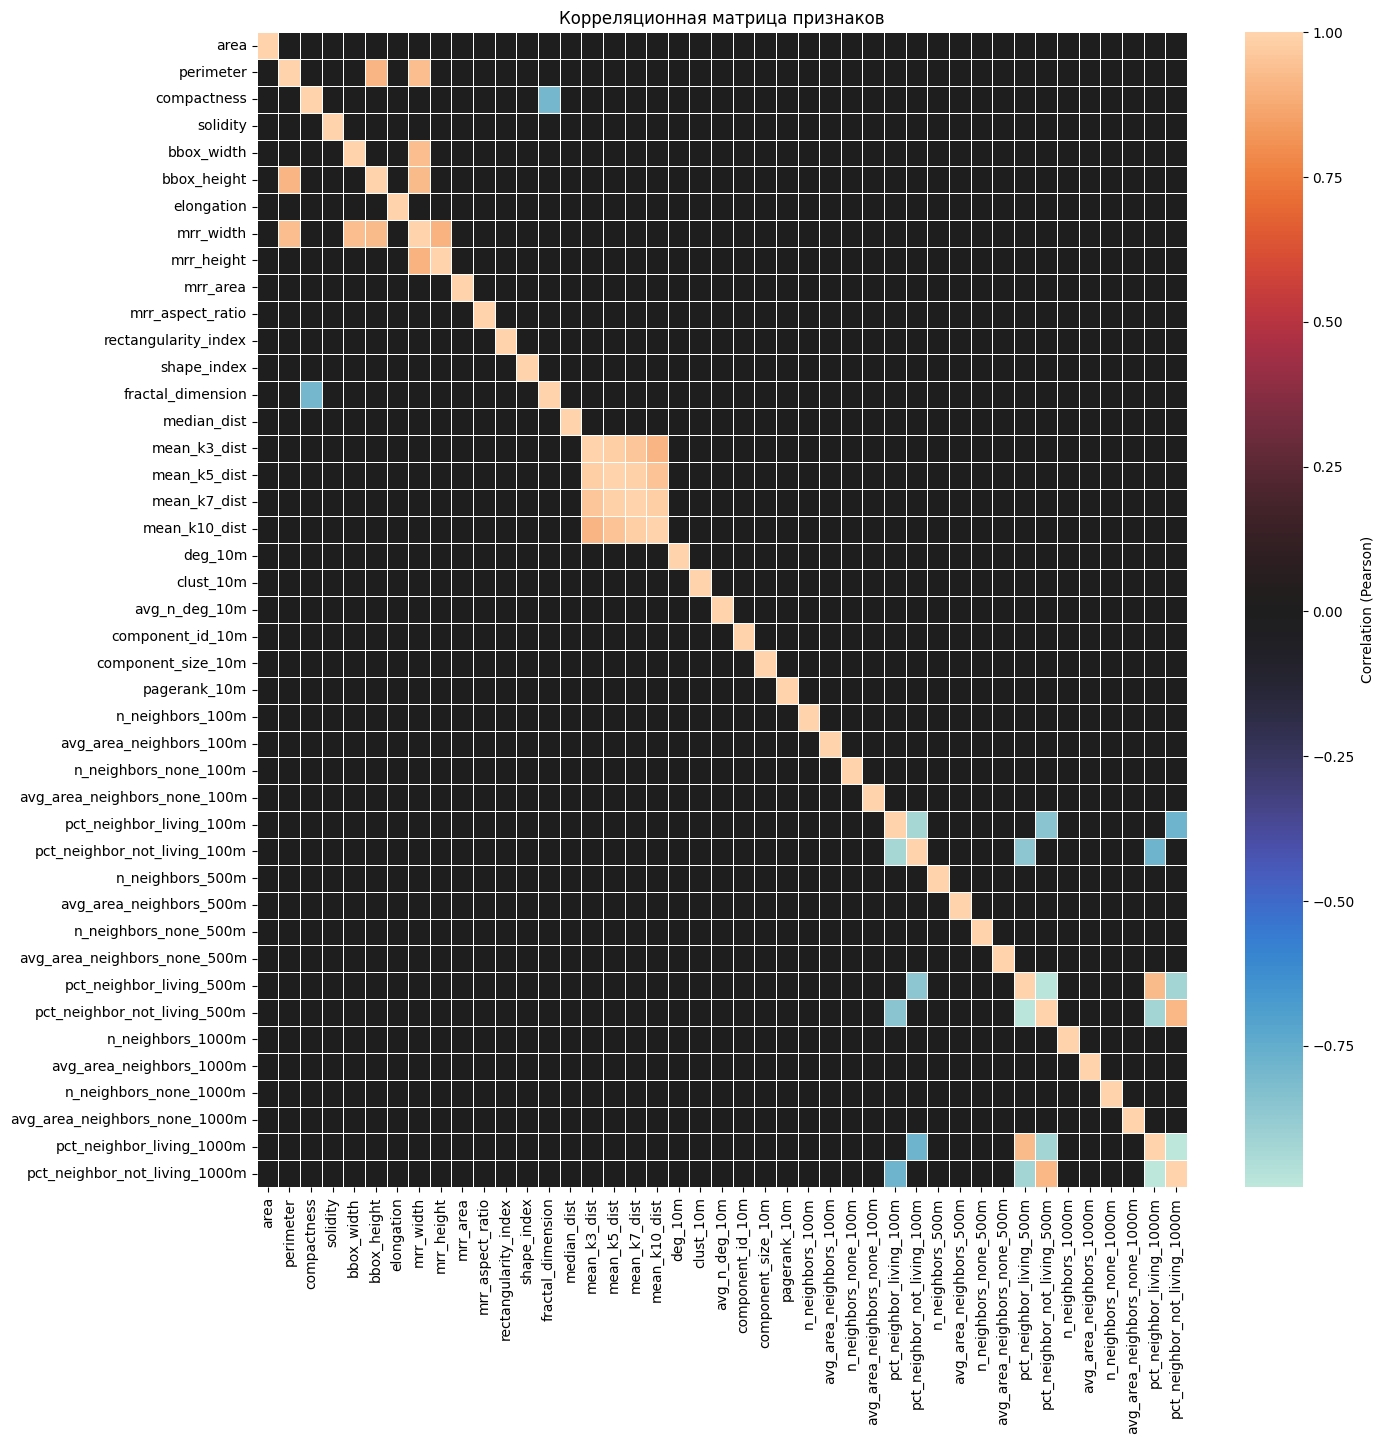

In [67]:
# корреляционная матрица
corr = pd.DataFrame(X_train, columns=feature_cols).corr(method='pearson')

# визуализация
plt.figure(figsize=(15, 15))
sns.heatmap(
    corr[(corr > 0.9) | (corr < -0.6)].fillna(0),
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation (Pearson)'},
)
plt.title("Корреляционная матрица признаков")
plt.show()

In [68]:
XGB_fi = voting.named_estimators_['XGB'].feature_importances_ / max(voting.named_estimators_['XGB'].feature_importances_)
LGBM_fi = voting.named_estimators_['LGBM'].feature_importances_ / max(voting.named_estimators_['LGBM'].feature_importances_)
RF_fi = voting.named_estimators_['RF'].feature_importances_ / max(voting.named_estimators_['RF'].feature_importances_)

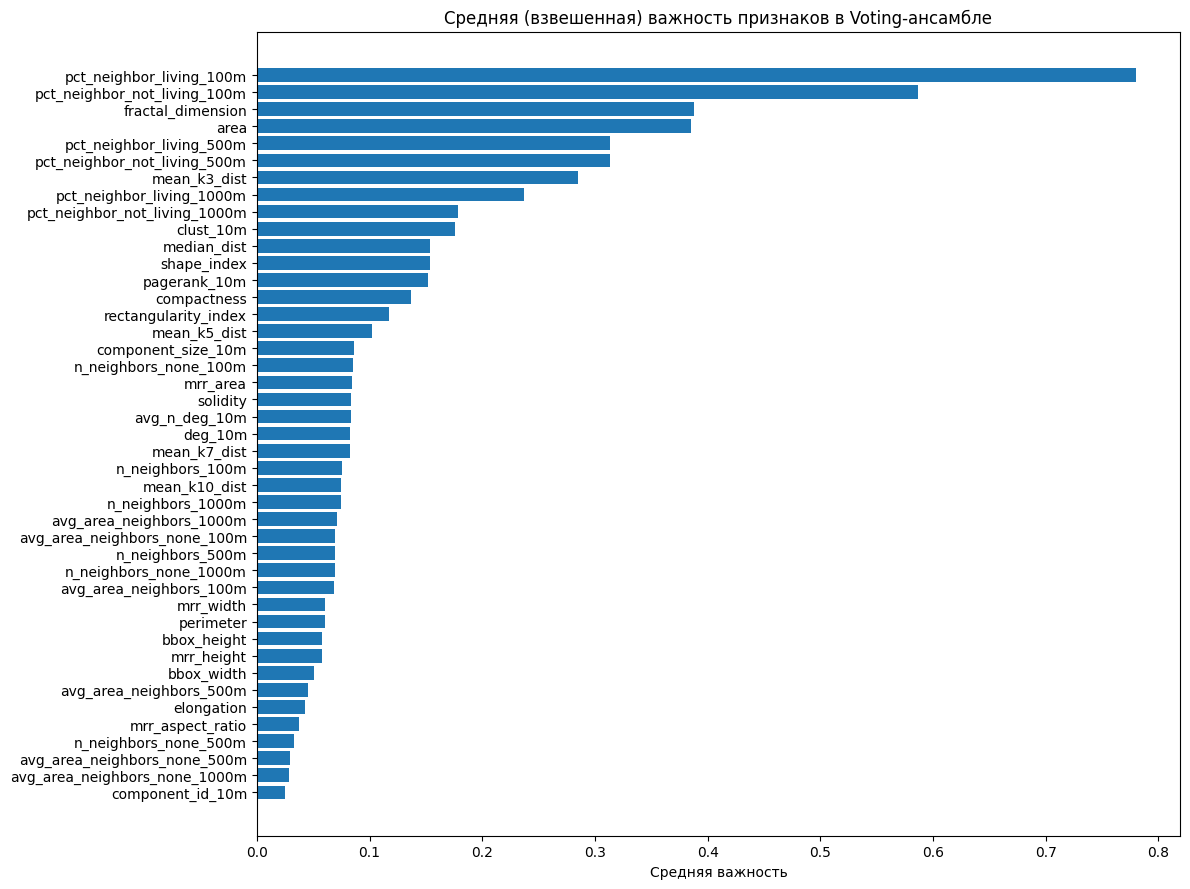

,XGB_importance,LGBM_importance,RF_importance,Weighted_mean
feature,,,,
pct_neighbor_living_100m,1.000000,0.340741,1.000000,0.780247
pct_neighbor_not_living_100m,0.465970,0.392593,0.900914,0.586493
fractal_dimension,0.053248,0.774074,0.336820,0.388047
area,0.034517,1.000000,0.120227,0.384915
pct_neighbor_living_500m,0.090097,0.388889,0.462157,0.313714
pct_neighbor_not_living_500m,0.051162,0.170370,0.719138,0.313557
mean_k3_dist,0.060031,0.703704,0.090303,0.284679
pct_neighbor_living_1000m,0.012006,0.351852,0.346543,0.236800
pct_neighbor_not_living_1000m,0.012458,0.237037,0.286395,0.178630


In [69]:
df_importances = pd.DataFrame({
    'feature': feature_cols,
    'XGB_importance': XGB_fi,
    'LGBM_importance': LGBM_fi,
    'RF_importance': RF_fi
})

df_importances.set_index('feature', inplace=True)
df_importances = df_importances.sort_values(by='XGB_importance', ascending=False)

df_importances['Weighted_mean'] = (
    df_importances['XGB_importance'] +
    df_importances['LGBM_importance'] +
    df_importances['RF_importance']
) / (3)

df_importances.sort_values(by='Weighted_mean', ascending=False, inplace=True)

plt.figure(figsize=(12, 9))
plt.barh(df_importances.index, df_importances['Weighted_mean'])
plt.gca().invert_yaxis()
plt.title("Средняя (взвешенная) важность признаков в Voting-ансамбле")
plt.xlabel("Средняя важность")
plt.tight_layout()
plt.show()

df_importances


In [70]:
m = test_gdf_kem[['geometry', 'target', 'predict']].explore('predict', tiles='Carto DB Positron')
test_gdf_kem[['geometry', 'target', 'predict']].explore('target', m=m)

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from blocksnet.enums import LandUse, LandUseCategory

# blocks_list — список GeoDataFrame, один город = один элемент
# если у вас уже есть этот список, просто присвойте:
# blocks_list = my_city_gdfs

def map_land_use_category(value):
    if isinstance(value, LandUseCategory):
        return value
    if isinstance(value, LandUse):
        return LandUseCategory.from_land_use(value)
    if isinstance(value, str):
        try:
            lu = LandUse(value.lower())
        except ValueError:
            return None
        return LandUseCategory.from_land_use(lu)
    return None

# ---------- утилиты ----------
def polygon_holes_area(geom):
    if geom is None or geom.is_empty:
        return 0.0
    if geom.geom_type == "Polygon":
        # сумма площадей внутренних колец
        return sum(abs(poly.area) for poly in [geom] for ring in geom.interiors) if len(geom.interiors) else 0.0
    if geom.geom_type == "MultiPolygon":
        total = 0.0
        for part in geom.geoms:
            if len(part.interiors):
                total += sum(abs(poly.area) for poly in [part] for ring in part.interiors)
        return total
    return 0.0

def oriented_bbox_angle(rect):
    if rect.is_empty:
        return 0.0
    coords = list(rect.exterior.coords)
    if len(coords) < 2:
        return 0.0
    edge = np.array(coords[1]) - np.array(coords[0])
    angle = np.arctan2(edge[1], edge[0])
    if angle < -np.pi / 2:
        angle += np.pi
    if angle > np.pi / 2:
        angle -= np.pi
    return angle

def count_exterior_vertices(geom):
    if geom.is_empty:
        return 0
    if geom.geom_type == "Polygon":
        return max(0, len(geom.exterior.coords) - 1)  # минус закрывающий дублирующий узел
    if geom.geom_type == "MultiPolygon":
        return int(np.sum([max(0, len(p.exterior.coords) - 1) for p in geom.geoms]))
    return 0

def count_holes(geom):
    if geom.is_empty:
        return 0
    if geom.geom_type == "Polygon":
        return len(geom.interiors)
    if geom.geom_type == "MultiPolygon":
        return int(np.sum([len(p.interiors) for p in geom.geoms]))
    return 0

def safe_div(a, b, default=0.0):
    return np.where(b != 0, a / b, default)

# ---------- основной конструктор ----------
def build_geometry_features_for_cities(city_gdfs: list[gpd.GeoDataFrame], batch_size=2000) -> gpd.GeoDataFrame:
    pieces = []

    for idx, city_gdf in enumerate(city_gdfs):
        category = city_gdf.category
        city_name = city_gdf.get("city", pd.Series([f"city_{idx}"] * len(city_gdf)))
        city = city_gdf.copy().reset_index(drop=True)
        city["__city_id__"] = city_name if isinstance(city_name, pd.Series) else f"city_{idx}"

        geom = city.geometry
        # базовые
        area = geom.area
        perimeter = geom.length

        # выпуклая оболочка и МВО (минимальный повернутый прямоугольник)
        convex = geom.convex_hull
        convex_area = convex.area.replace(0, np.nan)
        mbr = geom.minimum_rotated_rectangle()
        mbr_area = mbr.area.replace(0, np.nan)
        mbr_bounds = mbr.bounds
        width = (mbr_bounds.maxx - mbr_bounds.minx).replace(0, np.nan)
        height = (mbr_bounds.maxy - mbr_bounds.miny).replace(0, np.nan)
        mbr_perimeter = 2 * (width + height)

        # ориентация
        orientation = pd.Series([oriented_bbox_angle(g) for g in mbr], index=city.index)
        orientation_sin = np.sin(orientation)
        orientation_cos = np.cos(orientation)

        # представительные точки для «локальных» расстояний
        reps = geom.representative_point()
        coords = np.column_stack((reps.x.values, reps.y.values)).astype(float)

        n = len(coords)
        median_dist = np.zeros(n)
        mean_k3_dist = np.zeros(n)  # среднее расстояние до 3 ближайших (без себя)
        if n > 1:
            for i in range(0, n, batch_size):
                batch = coords[i:i + batch_size]
                dist_block = cdist(batch, coords)
                # маскируем «самого себя»
                row_idx, col_idx = np.indices(dist_block.shape)
                self_mask = (col_idx >= i) & (col_idx < i + batch_size) & (row_idx == (col_idx - i))
                dist_block[self_mask] = np.nan

                median_dist[i:i + batch_size] = np.nanmedian(dist_block, axis=1)
                # k-NN (k=3)
                part = np.sort(dist_block, axis=1)[:, :3]
                mean_k3_dist[i:i + batch_size] = np.nanmean(part, axis=1)
        else:
            median_dist[:] = 0
            mean_k3_dist[:] = 0

        # ----- ДОПОЛНИТЕЛЬНЫЕ ПРИЗНАКИ ФОРМЫ -----

        # 1) Компактность/круглотность
        circularity = safe_div(4 * np.pi * area, perimeter ** 2, 0.0)              # Polsby–Popper
        thinness_ratio = safe_div(2 * np.sqrt(np.pi * area), perimeter, 0.0)       # Schwartzberg (обратная криволинейность)
        shape_index = safe_div(area, perimeter, 0.0)                                # у вас уже был — оставим

        # 2) MBR-признаки
        rectangularity = safe_div(area, mbr_area, 0.0)
        aspect_ratio = safe_div(np.maximum(width, height), np.minimum(width, height), 1.0)
        squareness = safe_div(np.minimum(width, height), np.maximum(width, height), 0.0)
        mbr_fill_ratio = safe_div(perimeter, mbr_perimeter.replace(0, np.nan), np.nan)  # насколько контур «длиннее» периметра MBR

        # 3) Выпуклость/впадины
        solidity = safe_div(area, convex_area, 0.0)
        concavity_ratio = 1 - solidity  # доля «потерь» к выпуклой оболочке
        convexity_index = safe_div(convex_area, area.replace(0, np.nan), np.nan)  # обратный solidity

        # 5) Эквивалентная окружность
        equiv_diameter = 2 * np.sqrt(area / np.pi)
        equiv_circumference = np.pi * equiv_diameter
        perimeter_to_equiv_circ = safe_div(perimeter, equiv_circumference.replace(0, np.nan), 0.0)

        # 6) Сложность контура
        vertices_exterior = pd.Series([count_exterior_vertices(g) for g in geom], index=city.index)
        perimeter_per_vertex = safe_div(perimeter, vertices_exterior.replace(0, np.nan), 0.0)

        # 7) Лог-версии и стабилизация масштаба
        area_log = np.log1p(area)
        perimeter_log = np.log1p(perimeter)
        mbr_area_log = np.log1p(mbr_area)
        convex_area_log = np.log1p(convex_area)
        shape_index_log = np.log1p(shape_index)
        # rectangularity_log = np.log1p(rectangularity)
        # aspect_ratio_log = np.log1p(aspect_ratio)
        # squareness_log = np.log1p(squareness)
        # solidity_log = np.log1p(solidity)
        # concavity_ratio_log = np.log1p(concavity_ratio)
        # convexity_index_log = np.log1p(convexity_index)
        equiv_diameter_log = np.log1p(equiv_diameter)
        # vertices_exterior_log = np.log1p(vertices_exterior)
        # perimeter_per_vertex_log = np.log1p(perimeter_per_vertex)
        median_dist_log = np.log1p(median_dist)
        mean_k3_dist_log = np.log1p(mean_k3_dist)

        # 8) «Фрактальность» (псевдо-оценка)
        # Чем больше отношение log(P)/log(A), тем «неровнее» граница (грубая метрика)
        with np.errstate(divide='ignore', invalid='ignore'):
            fractal_dimension = safe_div(np.log(perimeter.replace(0, np.nan)), np.log(area.replace(0, np.nan)), np.nan)

        # 9) Нормировки относительно MBR
        area_over_mbr_diag2 = safe_div(area, (width**2 + height**2).replace(0, np.nan), 0.0)
        perimeter_over_mbr_diag = safe_div(perimeter, np.sqrt((width**2 + height**2)).replace(0, np.nan), 0.0)

        # 10) Нормировки относительно выпуклой оболочки
        perimeter_over_convex_perimeter = safe_div(perimeter, convex.length.replace(0, np.nan), 0.0)

        # 11) Координаты центров (как чисто геометрические признаки положения)
        # cent_x = reps.x
        # cent_y = reps.y

        # собираем
        features = pd.DataFrame({
            "__city_id__": city["__city_id__"],

            # базовые
            "area": area,
            "perimeter": perimeter,

            # компактность/круглотность
            "circularity": circularity,
            "thinness_ratio": thinness_ratio,
            "shape_index": shape_index,

            # MBR
            "rectangularity": rectangularity,
            "aspect_ratio": aspect_ratio,
            "squareness": squareness,
            "mbr_fill_ratio": mbr_fill_ratio,

            # выпуклость/впадины
            "solidity": solidity,
            "concavity_ratio": concavity_ratio,
            "convexity_index": convexity_index,

            # эквивалентная окружность
            "equiv_diameter": equiv_diameter,
            "perimeter_to_equiv_circ": perimeter_to_equiv_circ,

            # сложность контура
            "vertices_exterior": vertices_exterior.astype(float),
            "perimeter_per_vertex": perimeter_per_vertex,

            # ориентация
            "orientation_sin": orientation_sin,
            "orientation_cos": orientation_cos,

            # «локальные» расстояния
            "median_dist_representative": median_dist,
            "mean_k3_dist": mean_k3_dist,

            # нормировки/логи
            "fractal_dimension": fractal_dimension,
            "area_over_mbr_diag2": area_over_mbr_diag2,
            "perimeter_over_mbr_diag": perimeter_over_mbr_diag,
            # "perimeter_over_convex_perimeter": perimeter_over_convex_perimeter,

            # координаты центров (геометрия → положение)
            # "centroid_x": cent_x,
            # "centroid_y": cent_y,

            # целевая метка
            "category": category
        }, index=city.index)

        features["geometry"] = geom
        pieces.append(features)

    return gpd.GeoDataFrame(pd.concat(pieces, ignore_index=True), geometry="geometry")


# Применяем
geometry_features = build_geometry_features_for_cities(blocks_gdf)
geometry_features.dropna(inplace=True)
dataset = geometry_features.copy()
dataset["category"] = geometry_features["category"].astype("category").cat.codes
label_mapping = dict(enumerate(geometry_features["category"].astype("category").cat.categories))

In [4]:
# --- Очистка, фильтрация и подготовка выборки для обучения ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# 4. Универсальное удаление выбросов по IQR
num_cols = dataset.select_dtypes(include=[np.number]).columns.drop(["category"])
clean = dataset.copy()
for col in num_cols:
    Q1, Q3 = clean[col].quantile([0.01, 0.99])
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    clean = clean[(clean[col] >= low) & (clean[col] <= high)]


In [5]:
# 6. Масштабирование
X = clean.drop(columns=["category", "geometry", "__city_id__"])
y = clean["category"].to_numpy()

scaler = StandardScaler()
X = scaler.fit_transform(X)

# 7. Балансировка классов (SMOTE)
# smote = SMOTE(random_state=42, k_neighbors=3)
# X_bal, y_bal = smote.fit_resample(X_scaled, y)

In [6]:
clean['category'].value_counts()

category
0    1173302
1     113042
3      74588
2      46025
Name: count, dtype: int64

In [7]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42, sampling_strategy={0: int(len(y[y==2]) * 1.2)})
X, y = rus.fit_resample(X, y)

# 8. Разделение train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 9. Веса классов
classes = np.unique(y_train)
class_weights_vec = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights_vec))
class_weights_readable = {label_mapping[k].name: float(v.round(2)) for k, v in class_weights.items()}

print("Class weights:", class_weights_readable)
print(f"Финальная выборка: {X_train.shape[0]} train / {X_test.shape[0]} test / {len(classes)} классов")

Class weights: {'RESIDENTIAL': 1.31, 'INDUSTRIAL': 0.64, 'BUSINESS': 1.57, 'RECREATION': 0.97}
Финальная выборка: 216663 train / 72222 test / 4 классов


In [8]:
from sklearn.ensemble import VotingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- Базовые модели ---
estimators = [
    ("rf", RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )),
    ("xgb", XGBClassifier(
        n_estimators=600,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="mlogloss",
        n_jobs=8,
        random_state=42
    )),
    ("lgb", LGBMClassifier(
        n_estimators=800,
        max_depth=10,
        learning_rate=0.05,
        class_weight="balanced",
        num_threads=8,
        random_state=42
    )),
    ("hgb", HistGradientBoostingClassifier(
        max_iter=500,
        max_depth=8,
        learning_rate=0.05,
        random_state=42
    )),
]

# --- Ансамбль ---
model = VotingClassifier(
    estimators=estimators,
    voting="soft",          # усреднение вероятностей (лучше, чем majority vote)
    weights=[1, 1.5, 1.5, 1],  # можно скорректировать веса, если LGB/XGB дают лучшую валидацию
    n_jobs=-1
)

model.fit(X_train, y_train)

,estimators,"[('rf', ...), ('xgb', ...), ...]"
,voting,'soft'
,weights,"[1, 1.5, ...]"
,n_jobs,-1
,flatten_transform,True
,verbose,False
,n_estimators,400
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,5


In [9]:
y_pred = model.predict(X_test)

d:\programming\github\blocksnet\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification report:

              precision    recall  f1-score   support

 RESIDENTIAL       0.45      0.31      0.37     13808
  INDUSTRIAL       0.50      0.74      0.59     28261
    BUSINESS       0.29      0.10      0.15     11506
  RECREATION       0.41      0.37      0.39     18647

    accuracy                           0.46     72222
   macro avg       0.41      0.38      0.38     72222
weighted avg       0.43      0.46      0.43     72222



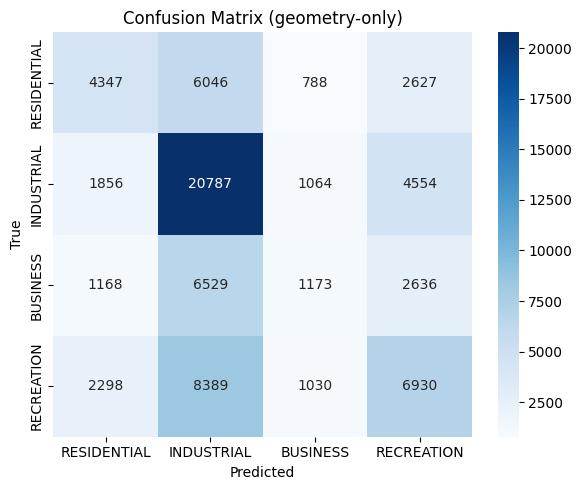

In [10]:
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=[label_mapping[c].name for c in classes]))

cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=[label_mapping[c].name for c in classes],
            yticklabels=[label_mapping[c].name for c in classes],
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (geometry-only)")
plt.tight_layout()
plt.show()

# rf_feature_importances = model.named_steps["rf"].feature_importances_
# feat_imp = pd.Series(rf_feature_importances, index=X.columns).sort_values(ascending=False)
# plt.figure(figsize=(8, 5))
# feat_imp.plot(kind="barh")
# plt.gca().invert_yaxis()
# plt.title("Top geometry features by importance")
# plt.tight_layout()
# plt.show()

In [11]:
probs = model.predict_proba(X_test)
print(np.mean(probs, axis=0))  # средние вероятности по классам


d:\programming\github\blocksnet\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[0.21484366 0.32942534 0.20117678 0.25455422]


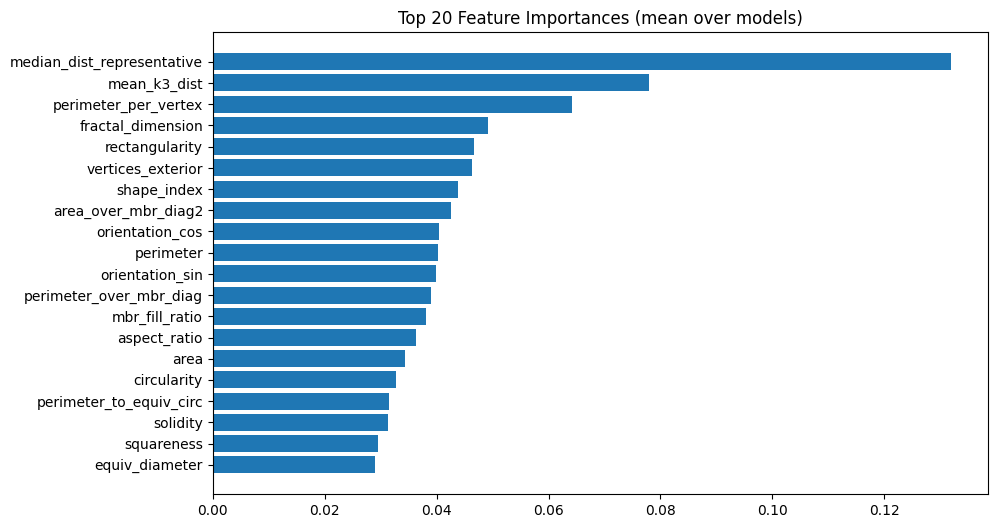

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# усредняем важности по моделям, где они доступны
importances = []
names = clean.drop(columns=["category", "geometry", "__city_id__"]).columns

for name, est in model.named_estimators_.items():
    if hasattr(est, "feature_importances_"):
        imp = est.feature_importances_
        # Нормализуем важности для каждой модели
        if imp.sum() > 0:
            imp = imp / imp.sum()  # нормализуем к сумме 1.0
        importances.append(imp)

mean_importance = np.mean(importances, axis=0)
importance_df = pd.DataFrame({"feature": names, "importance": mean_importance})
importance_df.sort_values("importance", ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df.feature.head(20), importance_df.importance.head(20))
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (mean over models)")
plt.show()


